# Configuración inicial

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q sentence-transformers xgboost

## 01 - Librerias y configuración

In [ ]:
import os
import gc
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

from sentence_transformers import SentenceTransformer

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

### RUTAS

NEWS_PATH = "/content/drive/MyDrive/EAFIT/TESIS/RZK/news_raw_colombia_con_fuente.csv"
PRICES_PATH = "/content/drive/MyDrive/EAFIT/TESIS/RZK/precios_colombia.csv"

EMBEDDINGS_CACHE_PATH = "/content/drive/MyDrive/EAFIT/TESIS/RZK/news_embeddings_mpnet.npy"
NEWS_WITH_EMB_CACHE_PATH = "/content/drive/MyDrive/EAFIT/TESIS/RZK/news_with_embedding_index.csv"

### Conf adicionales
TRAIN_END = "2023-12-31"
VAL_START = "2024-01-01"
VAL_END = "2024-12-31"
TEST_START = "2025-01-01"
TEST_END = "2025-12-31"

EMBEDDING_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

ROLLING_WINDOW_NEWS = 5
LOOKBACK_DAYS = 20

BATCH_SIZE_EMBEDDINGS = 32
BATCH_SIZE_DL = 64

EPOCHS_DL = 25
PATIENCE_DL = 5
LEARNING_RATE_DL = 1e-3

# Rolling horizon 2025
ROLLING_RETRAIN_EVERY_N_DAYS = 1
MIN_TRAIN_ROWS_ROLLING = 300

DEVICE: cpu


## 02 - Carga de los datos

In [ ]:
news_df = pd.read_csv(NEWS_PATH)
prices_df = pd.read_csv(PRICES_PATH)

news_df["fecha"] = pd.to_datetime(news_df["fecha"])
prices_df["fecha"] = pd.to_datetime(prices_df["fecha"])

news_df["stock"] = news_df["stock"].astype(str)
prices_df["stock"] = prices_df["stock"].astype(str)

news_df = news_df.sort_values(["stock", "fecha"]).reset_index(drop=True)
prices_df = prices_df.sort_values(["stock", "fecha"]).reset_index(drop=True)

print("Noticias:", news_df.shape)
print("Precios:", prices_df.shape)

display(news_df.head())
display(prices_df.head())

print("\nColumnas noticias:")
print(news_df.columns.tolist())

print("\nColumnas precios:")
print(prices_df.columns.tolist())

print("\nRango noticias:", news_df["fecha"].min(), "->", news_df["fecha"].max())
print("Rango precios:", prices_df["fecha"].min(), "->", prices_df["fecha"].max())

print("\nStocks noticias:", sorted(news_df["stock"].unique()))
print("Stocks precios:", sorted(prices_df["stock"].unique()))

Noticias: (3000, 19)
Precios: (5008, 12)


,fecha,stock,company_name,title,summary,text,source,domain,url,query_used,source_type,is_priority_source,relevance_score,is_relevant,sentiment_label,sentiment_value,sentiment_score,extraction_date,notes
0,2021-01-13,ARG,Grupo Argos,Grupo Argos anuncia ambicioso plan de recompra...,La junta directiva autorizó un cupo millonario...,La junta directiva autorizó un cupo millonario...,Valora Analitik,valoraanalitik.com,https://www.valoraanalitik.com/contenido/arg-n...,"""Grupo Argos"" AND ""recompra de acciones""",medio económico,True,0.72,True,POS,1,0.91,2026-05-18,Pipeline de ingesta histórico robusto. Texto c...
1,2021-01-14,ARG,Grupo Argos,Grupo Argos convoca a reunión extraordinaria d...,El orden del día contempla modificaciones esta...,El orden del día contempla modificaciones esta...,El Espectador,elespectador.com,https://www.elespectador.com/contenido/arg-not...,Grupo Argos AND asambleas,prensa,True,0.71,True,NEU,0,0.96,2026-05-18,Pipeline de ingesta histórico robusto. Texto c...
2,2021-01-14,ARG,Grupo Argos,Grupo Argos anuncia ambicioso plan de recompra...,La junta directiva autorizó un cupo millonario...,La junta directiva autorizó un cupo millonario...,La República,larepublica.co,https://www.larepublica.co/contenido/arg-notic...,"""Grupo Argos"" AND ""recompra de acciones""",medio económico,True,0.88,True,POS,1,0.92,2026-05-18,Pipeline de ingesta histórico robusto. Texto c...
3,2021-01-24,ARG,Grupo Argos,Odinsa y Celsia reportan hitos de infraestruct...,Las filiales del grupo superaron las metas ope...,Las filiales del grupo superaron las metas ope...,Valora Analitik,valoraanalitik.com,https://www.valoraanalitik.com/contenido/arg-n...,Celsia OR Odinsa,medio económico,True,0.74,True,POS,1,0.77,2026-05-18,Pipeline de ingesta histórico robusto. Texto c...
4,2021-02-10,ARG,Grupo Argos,Cementos Argos consolida fusión estratégica en...,La operación genera sinergias operativas y exp...,La operación genera sinergias operativas y exp...,Reuters Latam,reuters.com,https://www.reuters.com/contenido/arg-noticia-...,Cementos Argos AND inversiones,prensa,False,0.96,True,POS,1,0.86,2026-05-18,Pipeline de ingesta histórico robusto. Texto c...


,fecha,stock,open,high,low,close,volume,return_1d,volatility_5,ma_5,ma_10,target
0,2021-01-14,ARG,14000.0,14000.0,13600.0,11268.315430,156940,0.019665,0.018500,11147.582227,11114.963379,0
1,2021-01-15,ARG,14000.0,14100.0,13800.0,11268.315430,108784,0.000000,0.012302,11179.777539,11130.842969,0
2,2021-01-18,ARG,13900.0,13900.0,13670.0,11187.826172,117277,-0.007143,0.013117,11195.875000,11131.480469,1
3,2021-01-19,ARG,13960.0,14000.0,13840.0,11236.117188,46560,0.004316,0.012656,11202.313867,11144.140234,0
4,2021-01-20,ARG,13900.0,13960.0,13840.0,11187.826172,129726,-0.004298,0.010528,11229.680078,11135.186914,0



Columnas noticias:
['fecha', 'stock', 'company_name', 'title', 'summary', 'text', 'source', 'domain', 'url', 'query_used', 'source_type', 'is_priority_source', 'relevance_score', 'is_relevant', 'sentiment_label', 'sentiment_value', 'sentiment_score', 'extraction_date', 'notes']

Columnas precios:
['fecha', 'stock', 'open', 'high', 'low', 'close', 'volume', 'return_1d', 'volatility_5', 'ma_5', 'ma_10', 'target']

Rango noticias: 2021-01-01 00:00:00 -> 2025-12-31 00:00:00
Rango precios: 2021-01-14 00:00:00 -> 2025-12-31 00:00:00

Stocks noticias: ['ARG', 'CIBEST', 'EC', 'NCH']
Stocks precios: ['ARG', 'CIBEST', 'EC', 'NCH']


## 03 - Pre validación

In [ ]:
required_news_cols = ["fecha", "stock", "title", "summary", "text"]
required_price_cols = [
    "fecha", "stock", "open", "high", "low", "close",
    "volume", "return_1d", "volatility_5", "ma_5", "ma_10", "target"
]

missing_news = [c for c in required_news_cols if c not in news_df.columns]
missing_prices = [c for c in required_price_cols if c not in prices_df.columns]

if missing_news:
    raise ValueError(f"Faltan columnas en noticias: {missing_news}")

if missing_prices:
    raise ValueError(f"Faltan columnas en precios: {missing_prices}")

print("Valores target:")
print(prices_df["target"].value_counts(dropna=False))

print("\nNoticias por stock:")
print(news_df["stock"].value_counts())

print("\nPrecios por stock:")
print(prices_df["stock"].value_counts())

print("\nDuplicados precios fecha-stock:", prices_df.duplicated(["fecha", "stock"]).sum())
print("Duplicados noticias exactos fecha-stock-url:", news_df.duplicated(["fecha", "stock", "url"]).sum() if "url" in news_df.columns else "Sin URL")

Valores target:
target
0    2804
1    2204
Name: count, dtype: int64

Noticias por stock:
stock
EC        1236
CIBEST     720
NCH        620
ARG        424
Name: count, dtype: int64

Precios por stock:
stock
ARG       1276
NCH       1275
EC        1246
CIBEST    1211
Name: count, dtype: int64

Duplicados precios fecha-stock: 0
Duplicados noticias exactos fecha-stock-url: 0


# Preparación de datos

## 04 - Construcción texto para embeddings

In [ ]:
for col in ["title", "summary", "text"]:
    news_df[col] = news_df[col].fillna("").astype(str)

# Escenario principal:
# Usa título + resumen + texto completo.
news_df["texto_modelo"] = (
    news_df["title"].str.strip()
    + ". "
    + news_df["summary"].str.strip()
    + ". "
    + news_df["text"].str.strip()
)

# ESCENARIO ALTERNATIVO:
news_df["texto_modelo"] = (
    news_df["title"].str.strip()
    + ". "
    + news_df["summary"].str.strip()
)

# news_df["texto_modelo"] = (
#     news_df["texto_modelo"]
#     .str.replace(r"\s+", " ", regex=True)
#     .str.strip()
# )

news_df["texto_modelo"] = news_df["texto_modelo"].replace("", "sin información textual disponible")

print(news_df[["fecha", "stock", "texto_modelo"]].head())
print("\nLongitud promedio del texto:", news_df["texto_modelo"].str.len().mean())

       fecha stock                                       texto_modelo
0 2021-01-13   ARG  Grupo Argos anuncia ambicioso plan de recompra...
1 2021-01-14   ARG  Grupo Argos convoca a reunión extraordinaria d...
2 2021-01-14   ARG  Grupo Argos anuncia ambicioso plan de recompra...
3 2021-01-24   ARG  Odinsa y Celsia reportan hitos de infraestruct...
4 2021-02-10   ARG  Cementos Argos consolida fusión estratégica en...

Longitud promedio del texto: 164.37666666666667


## 05 - Creación embeddings

In [ ]:
def create_or_load_embeddings(news_df, model_name, cache_path, batch_size=32):
    """
    Crea embeddings por noticia o los carga desde cache si ya existen.
    """
    if os.path.exists(cache_path):
        print(f"Cargando embeddings desde cache: {cache_path}")
        embeddings = np.load(cache_path)
        return embeddings

    print(f"Cargando modelo de embeddings: {model_name}")
    model = SentenceTransformer(model_name, device=DEVICE)

    texts = news_df["texto_modelo"].tolist()

    embeddings = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=False
    )

    np.save(cache_path, embeddings)
    print(f"Embeddings guardados en: {cache_path}")

    return embeddings


news_embeddings = create_or_load_embeddings(
    news_df=news_df,
    model_name=EMBEDDING_MODEL_NAME,
    cache_path=EMBEDDINGS_CACHE_PATH,
    batch_size=BATCH_SIZE_EMBEDDINGS
)

print("Shape embeddings:", news_embeddings.shape)

embedding_dim = news_embeddings.shape[1]
emb_cols = [f"emb_{i}" for i in range(embedding_dim)]

emb_df = pd.DataFrame(news_embeddings, columns=emb_cols)
news_emb_df = pd.concat([news_df.reset_index(drop=True), emb_df], axis=1)

print("Dataset noticias + embeddings:", news_emb_df.shape)
display(news_emb_df.head())

Cargando embeddings desde cache: /content/drive/MyDrive/EAFIT/TESIS/RZK/news_embeddings_mpnet.npy
Shape embeddings: (3000, 768)
Dataset noticias + embeddings: (3000, 788)


,fecha,stock,company_name,title,summary,text,source,domain,url,query_used,...,emb_758,emb_759,emb_760,emb_761,emb_762,emb_763,emb_764,emb_765,emb_766,emb_767
0,2021-01-13,ARG,Grupo Argos,Grupo Argos anuncia ambicioso plan de recompra...,La junta directiva autorizó un cupo millonario...,La junta directiva autorizó un cupo millonario...,Valora Analitik,valoraanalitik.com,https://www.valoraanalitik.com/contenido/arg-n...,"""Grupo Argos"" AND ""recompra de acciones""",...,-0.020209,-0.017829,-0.015261,0.121911,-0.037938,0.006511,-0.039632,0.021973,-0.148303,0.028295
1,2021-01-14,ARG,Grupo Argos,Grupo Argos convoca a reunión extraordinaria d...,El orden del día contempla modificaciones esta...,El orden del día contempla modificaciones esta...,El Espectador,elespectador.com,https://www.elespectador.com/contenido/arg-not...,Grupo Argos AND asambleas,...,0.067507,-0.004122,0.009067,0.083819,-0.011475,-0.106220,-0.024366,0.076866,-0.226765,0.084010
2,2021-01-14,ARG,Grupo Argos,Grupo Argos anuncia ambicioso plan de recompra...,La junta directiva autorizó un cupo millonario...,La junta directiva autorizó un cupo millonario...,La República,larepublica.co,https://www.larepublica.co/contenido/arg-notic...,"""Grupo Argos"" AND ""recompra de acciones""",...,-0.009542,-0.020313,-0.020899,0.139284,-0.034860,0.033249,-0.040326,0.020072,-0.136569,0.030018
3,2021-01-24,ARG,Grupo Argos,Odinsa y Celsia reportan hitos de infraestruct...,Las filiales del grupo superaron las metas ope...,Las filiales del grupo superaron las metas ope...,Valora Analitik,valoraanalitik.com,https://www.valoraanalitik.com/contenido/arg-n...,Celsia OR Odinsa,...,-0.024448,-0.027346,-0.050688,0.092257,0.016795,-0.126536,-0.044318,-0.019143,-0.038507,0.012961
4,2021-02-10,ARG,Grupo Argos,Cementos Argos consolida fusión estratégica en...,La operación genera sinergias operativas y exp...,La operación genera sinergias operativas y exp...,Reuters Latam,reuters.com,https://www.reuters.com/contenido/arg-noticia-...,Cementos Argos AND inversiones,...,0.026464,0.061022,-0.023277,0.152540,-0.021423,-0.216106,-0.044959,0.032300,-0.126124,0.024569


## 06 - Consolidación información

In [ ]:
sentiment_agg_dict = {}

if "sentiment_value" in news_emb_df.columns:
    sentiment_agg_dict["sentiment_value"] = ["mean", "min", "max", "std"]

if "sentiment_score" in news_emb_df.columns:
    sentiment_agg_dict["sentiment_score"] = ["mean", "min", "max", "std"]

daily_count = (
    news_emb_df
    .groupby(["fecha", "stock"])
    .size()
    .reset_index(name="n_noticias")
)

daily_embeddings = (
    news_emb_df
    .groupby(["fecha", "stock"])[emb_cols]
    .mean()
    .reset_index()
)

if sentiment_agg_dict:
    daily_sent = (
        news_emb_df
        .groupby(["fecha", "stock"])
        .agg(sentiment_agg_dict)
    )

    daily_sent.columns = [
        "_".join(col).strip()
        for col in daily_sent.columns.values
    ]

    daily_sent = daily_sent.reset_index()

    daily_news_features = (
        daily_embeddings
        .merge(daily_count, on=["fecha", "stock"], how="left")
        .merge(daily_sent, on=["fecha", "stock"], how="left")
    )
else:
    daily_news_features = (
        daily_embeddings
        .merge(daily_count, on=["fecha", "stock"], how="left")
    )

if "sentiment_label" in news_emb_df.columns:
    sent_pivot = (
        news_emb_df
        .assign(sentiment_label=news_emb_df["sentiment_label"].fillna("UNK"))
        .pivot_table(
            index=["fecha", "stock"],
            columns="sentiment_label",
            values="texto_modelo",
            aggfunc="count",
            fill_value=0
        )
        .reset_index()
    )

    sent_pivot.columns = [str(c) for c in sent_pivot.columns]

    label_cols = [c for c in sent_pivot.columns if c not in ["fecha", "stock"]]

    for c in label_cols:
        sent_pivot[f"pct_{c}"] = sent_pivot[c] / sent_pivot[label_cols].sum(axis=1)

    pct_cols = [c for c in sent_pivot.columns if c.startswith("pct_")]

    daily_news_features = daily_news_features.merge(
        sent_pivot[["fecha", "stock"] + pct_cols],
        on=["fecha", "stock"],
        how="left"
    )

print("Features diarias de noticias:", daily_news_features.shape)
display(daily_news_features.head())

Features diarias de noticias: (2399, 782)


,fecha,stock,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,...,sentiment_value_min,sentiment_value_max,sentiment_value_std,sentiment_score_mean,sentiment_score_min,sentiment_score_max,sentiment_score_std,pct_NEG,pct_NEU,pct_POS
0,2021-01-01,EC,-0.018816,0.157360,-0.016380,0.033212,0.035462,-0.050836,-0.087153,0.038454,...,1,1,0.000000,0.755,0.75,0.76,0.007071,0.0,0.0,1.0
1,2021-01-02,CIBEST,-0.038456,0.026882,-0.012274,-0.008300,0.006590,-0.018976,0.004410,-0.014201,...,-1,-1,NaN,0.810,0.81,0.81,NaN,1.0,0.0,0.0
2,2021-01-02,EC,-0.051338,0.142136,-0.011373,0.082390,0.027751,-0.117655,0.018088,-0.043930,...,-1,-1,NaN,0.780,0.78,0.78,NaN,1.0,0.0,0.0
3,2021-01-04,NCH,0.028909,0.152226,-0.007103,0.087210,0.142422,-0.049316,-0.042741,0.032045,...,0,0,NaN,0.900,0.90,0.90,NaN,0.0,1.0,0.0
4,2021-01-05,EC,0.014045,0.111129,-0.012106,0.006876,0.097552,-0.068205,-0.041998,-0.010318,...,-1,0,0.707107,0.870,0.77,0.97,0.141421,0.5,0.5,0.0


## 07 - Precios enriquecidos + Embeddings SIN forward fill

In [ ]:
# =========================================================
# 07 - Precios enriquecidos + Embeddings SIN forward fill
# =========================================================
# Objetivo del experimento:
#   1. Construir targets alternativos sobre TODOS los días bursátiles.
#   2. Construir features técnicas sobre TODOS los días bursátiles.
#   3. Luego cruzar con noticias usando INNER JOIN.
#   4. Conservar únicamente días fecha-stock con precio + noticia + embedding real.
#   5. NO aplicar forward fill a embeddings.
#   6. NO rellenar embeddings faltantes con cero.
#
# Nota metodológica importante:
#   Los targets t+5 y t+10 se calculan antes del filtro por noticias.
#   Por tanto, representan 5 y 10 ruedas bursátiles hacia adelante,
#   no 5 o 10 observaciones con noticia.
# =========================================================

prices_enriched_df = prices_df.copy()
prices_enriched_df = prices_enriched_df.sort_values(["stock", "fecha"]).reset_index(drop=True)

print("Shape precios originales:", prices_enriched_df.shape)
print("Shape features diarias de noticias:", daily_news_features.shape)

# ---------------------------------------------------------
# 1. Targets alternativos sobre la serie completa de precios
# ---------------------------------------------------------

HORIZONS = [1, 5, 10]

for h in HORIZONS:
    prices_enriched_df[f"future_return_{h}d"] = (
        prices_enriched_df
        .groupby("stock")["close"]
        .shift(-h) / prices_enriched_df["close"] - 1
    )

    prices_enriched_df[f"target_{h}d"] = (
        prices_enriched_df[f"future_return_{h}d"] > 0
    ).astype(float)

# Targets con zona neutral.
# Si el retorno futuro está entre -threshold y +threshold,
# se marca como NaN y se elimina solo para ese experimento.
NEUTRAL_THRESHOLDS = {
    "neutral_05": 0.005,  # ±0.5%
    "neutral_10": 0.010   # ±1.0%
}

for h in [5, 10]:
    for neutral_name, threshold in NEUTRAL_THRESHOLDS.items():
        target_col = f"target_{h}d_{neutral_name}"

        prices_enriched_df[target_col] = np.where(
            prices_enriched_df[f"future_return_{h}d"] > threshold,
            1,
            np.where(
                prices_enriched_df[f"future_return_{h}d"] < -threshold,
                0,
                np.nan
            )
        )

# Compatibilidad con el target original del notebook.
# Si ya existe target, lo conservamos; además dejamos target_1d como alternativa explícita.
if "target" in prices_enriched_df.columns:
    prices_enriched_df["target"] = prices_enriched_df["target"].astype(float)
else:
    prices_enriched_df["target"] = prices_enriched_df["target_1d"]

# ---------------------------------------------------------
# 2. Features técnicas ampliadas sobre la serie completa
# ---------------------------------------------------------

# Retorno diario base
prices_enriched_df["return_1d"] = (
    prices_enriched_df
    .groupby("stock")["close"]
    .pct_change()
)

# Retornos rezagados / momentum simple
for lag in [1, 2, 3, 5, 10, 20]:
    prices_enriched_df[f"return_lag_{lag}"] = (
        prices_enriched_df
        .groupby("stock")["close"]
        .pct_change(lag)
    )

# Medias móviles
for window in [5, 10, 20, 50]:
    prices_enriched_df[f"ma_{window}"] = (
        prices_enriched_df
        .groupby("stock")["close"]
        .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
    )

# Distancia del precio a medias móviles
for window in [5, 10, 20, 50]:
    prices_enriched_df[f"close_to_ma_{window}"] = (
        prices_enriched_df["close"] / prices_enriched_df[f"ma_{window}"] - 1
    )

# Volatilidad histórica
for window in [5, 10, 20]:
    prices_enriched_df[f"volatility_{window}"] = (
        prices_enriched_df
        .groupby("stock")["return_1d"]
        .transform(lambda x: x.rolling(window=window, min_periods=2).std())
    )

# Momentum respecto a ventanas
for window in [5, 10, 20]:
    prices_enriched_df[f"momentum_{window}"] = (
        prices_enriched_df
        .groupby("stock")["close"]
        .transform(lambda x: x / x.shift(window) - 1)
    )

# Rango intradía
prices_enriched_df["hl_range"] = (
    prices_enriched_df["high"] / prices_enriched_df["low"] - 1
)

# Retorno open-close
prices_enriched_df["oc_return"] = (
    prices_enriched_df["close"] / prices_enriched_df["open"] - 1
)

# Posición del cierre dentro del rango diario
prices_enriched_df["close_position"] = (
    (prices_enriched_df["close"] - prices_enriched_df["low"]) /
    (prices_enriched_df["high"] - prices_enriched_df["low"])
)

# Volumen relativo
for window in [5, 10, 20]:
    prices_enriched_df[f"volume_ma_{window}"] = (
        prices_enriched_df
        .groupby("stock")["volume"]
        .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
    )

    prices_enriched_df[f"volume_rel_{window}"] = (
        prices_enriched_df["volume"] / prices_enriched_df[f"volume_ma_{window}"] - 1
    )

prices_enriched_df = prices_enriched_df.replace([np.inf, -np.inf], np.nan)

# ---------------------------------------------------------
# 3. Merge INNER: solo fecha-stock con precio + noticia real
# ---------------------------------------------------------

dataset = prices_enriched_df.merge(
    daily_news_features,
    on=["fecha", "stock"],
    how="inner"
)

dataset = dataset.sort_values(["stock", "fecha"]).reset_index(drop=True)

print("\nDataset después de INNER JOIN precios + noticias:")
print(dataset.shape)

# ---------------------------------------------------------
# 4. Identificar columnas de noticias no embedding
# ---------------------------------------------------------

news_numeric_cols = [
    c for c in daily_news_features.columns
    if c not in ["fecha", "stock"] and c not in emb_cols
]

# En este experimento, si la fila existe es porque sí hubo noticia ese día.
dataset["has_news_today"] = 1

# ---------------------------------------------------------
# 5. Validaciones de nulos
# ---------------------------------------------------------

print("\nNulos en embeddings después del inner join:")
print(dataset[emb_cols].isna().sum().sum())

print("\nNulos en variables numéricas de noticias:")
if len(news_numeric_cols) > 0:
    print(
        dataset[news_numeric_cols]
        .isna()
        .sum()
        .sort_values(ascending=False)
        .head(20)
    )
else:
    print("No hay variables numéricas de noticias adicionales.")

print("\nNulos en variables principales:")
print(dataset[["fecha", "stock", "target"]].isna().sum())

# ---------------------------------------------------------
# 6. Rellenar únicamente variables agregadas no embedding
# ---------------------------------------------------------
# Ejemplo: std de sentimiento puede quedar NaN si solo hay una noticia.
# Los embeddings NO se rellenan.
# ---------------------------------------------------------

for c in news_numeric_cols:
    if c in dataset.columns:
        dataset[c] = dataset[c].fillna(0)

# Validar que no haya embeddings faltantes
embedding_nulls = dataset[emb_cols].isna().sum().sum()

if embedding_nulls > 0:
    raise ValueError(
        f"Hay {embedding_nulls} valores nulos en embeddings. "
        "Revisar daily_news_features antes de entrenar."
    )

# ---------------------------------------------------------
# 7. Crear embeddings rolling SOLO sobre días con noticia
# ---------------------------------------------------------
# Nota metodológica:
#   El rolling de embeddings se calcula sobre las últimas N observaciones
#   disponibles con noticia para cada acción. No usa forward fill.
# ---------------------------------------------------------

rolling_emb_cols = [f"{c}_roll{ROLLING_WINDOW_NEWS}" for c in emb_cols]

for stock, idx in dataset.groupby("stock").groups.items():
    idx = list(idx)

    rolled = (
        dataset.loc[idx, emb_cols]
        .rolling(window=ROLLING_WINDOW_NEWS, min_periods=1)
        .mean()
        .values
    )

    dataset.loc[idx, rolling_emb_cols] = rolled

rolling_news_cols = []

for c in news_numeric_cols + ["has_news_today"]:
    new_col = f"{c}_roll{ROLLING_WINDOW_NEWS}"
    rolling_news_cols.append(new_col)

    dataset[new_col] = (
        dataset
        .groupby("stock")[c]
        .transform(lambda x: x.rolling(window=ROLLING_WINDOW_NEWS, min_periods=1).mean())
    )

# ---------------------------------------------------------
# 8. Diagnóstico de cobertura
# ---------------------------------------------------------

coverage_prices = (
    prices_df
    .groupby("stock")
    .size()
    .reset_index(name="filas_precios_originales")
)

coverage_dataset = (
    dataset
    .groupby("stock")
    .size()
    .reset_index(name="filas_con_precio_y_noticia")
)

coverage = coverage_prices.merge(
    coverage_dataset,
    on="stock",
    how="left"
)

coverage["filas_con_precio_y_noticia"] = (
    coverage["filas_con_precio_y_noticia"]
    .fillna(0)
    .astype(int)
)

coverage["pct_con_noticia"] = (
    coverage["filas_con_precio_y_noticia"] /
    coverage["filas_precios_originales"]
)

print("\nCobertura precio + noticia por acción:")
display(coverage)

print("\nRango temporal final por stock:")
display(
    dataset
    .groupby("stock")
    .agg(
        fecha_min=("fecha", "min"),
        fecha_max=("fecha", "max"),
        filas=("fecha", "size"),
        noticias_promedio=("n_noticias", "mean")
    )
    .reset_index()
)

print("\nDistribución de targets alternativos:")
target_diagnostic_cols = [
    "target", "target_1d", "target_5d", "target_10d",
    "target_5d_neutral_05", "target_10d_neutral_05",
    "target_5d_neutral_10", "target_10d_neutral_10"
]
for c in target_diagnostic_cols:
    if c in dataset.columns:
        print(f"\n{c}:")
        print(dataset[c].value_counts(normalize=True, dropna=False))

print("\nDataset final sin forward fill:")
print(dataset.shape)

display(dataset.head())


Shape precios originales: (5008, 12)
Shape features diarias de noticias: (2399, 782)

Dataset después de INNER JOIN precios + noticias:
(1625, 828)

Nulos en embeddings después del inner join:
0

Nulos en variables numéricas de noticias:
sentiment_score_std     1266
sentiment_value_std     1266
n_noticias                 0
sentiment_value_mean       0
sentiment_value_max        0
sentiment_value_min        0
sentiment_score_min        0
sentiment_score_mean       0
sentiment_score_max        0
pct_NEG                    0
pct_NEU                    0
pct_POS                    0
dtype: int64

Nulos en variables principales:
fecha     0
stock     0
target    0
dtype: int64

Cobertura precio + noticia por acción:


,stock,filas_precios_originales,filas_con_precio_y_noticia,pct_con_noticia
0,ARG,1276,267,0.209248
1,CIBEST,1211,389,0.321222
2,EC,1246,613,0.491974
3,NCH,1275,356,0.279216



Rango temporal final por stock:


,stock,fecha_min,fecha_max,filas,noticias_promedio
0,ARG,2021-01-14,2025-12-23,267,1.101124
1,CIBEST,2021-01-22,2025-12-22,389,1.195373
2,EC,2021-01-19,2025-12-29,613,1.401305
3,NCH,2021-01-15,2025-12-31,356,1.196629



Distribución de targets alternativos:

target:
target
0.0    0.552615
1.0    0.447385
Name: proportion, dtype: float64

target_1d:
target_1d
0.0    0.552615
1.0    0.447385
Name: proportion, dtype: float64

target_5d:
target_5d
1.0    0.514462
0.0    0.485538
Name: proportion, dtype: float64

target_10d:
target_10d
1.0    0.528615
0.0    0.471385
Name: proportion, dtype: float64

target_5d_neutral_05:
target_5d_neutral_05
1.0    0.455385
0.0    0.407385
NaN    0.137231
Name: proportion, dtype: float64

target_10d_neutral_05:
target_10d_neutral_05
1.0    0.491077
0.0    0.412308
NaN    0.096615
Name: proportion, dtype: float64

target_5d_neutral_10:
target_5d_neutral_10
1.0    0.404923
0.0    0.353846
NaN    0.241231
Name: proportion, dtype: float64

target_10d_neutral_10:
target_10d_neutral_10
1.0    0.451077
0.0    0.368000
NaN    0.180923
Name: proportion, dtype: float64

Dataset final sin forward fill:
(1625, 1610)


,fecha,stock,open,high,low,close,volume,return_1d,volatility_5,ma_5,...,sentiment_value_max_roll5,sentiment_value_std_roll5,sentiment_score_mean_roll5,sentiment_score_min_roll5,sentiment_score_max_roll5,sentiment_score_std_roll5,pct_NEG_roll5,pct_NEU_roll5,pct_POS_roll5,has_news_today_roll5
0,2021-01-14,ARG,14000.0,14000.0,13600.0,11268.315430,156940,NaN,NaN,11268.315430,...,1.000000,0.707107,0.9400,0.920000,0.960000,0.028284,0.0,0.500,0.500,1.0
1,2021-02-10,ARG,13150.0,13450.0,13130.0,10584.166992,146099,-0.009789,0.007878,10653.385937,...,1.000000,0.353553,0.9000,0.890000,0.910000,0.014142,0.0,0.250,0.750,1.0
2,2021-02-22,ARG,12840.0,12840.0,12500.0,10334.654297,161526,0.015823,0.012664,10374.897070,...,0.666667,0.235702,0.9100,0.903333,0.916667,0.009428,0.0,0.500,0.500,1.0
3,2021-03-08,ARG,12430.0,12450.0,12200.0,10004.653320,56008,0.002419,0.009821,10160.799805,...,0.500000,0.176777,0.8875,0.882500,0.892500,0.007071,0.0,0.625,0.375,1.0
4,2021-03-10,ARG,12780.0,12780.0,12450.0,10286.362305,46778,0.015898,0.015671,10091.580078,...,0.200000,0.141421,0.8840,0.880000,0.888000,0.005657,0.2,0.500,0.300,1.0


## 08 - Definición de features ampliadas y escenarios

In [ ]:
# =========================================================
# 08 - Definición de features ampliadas y escenarios
# =========================================================
# Escenarios sin PCA y sin variables externas de mercado.
# Tampoco se separan modelos por acción.
# =========================================================

TECH_FEATURES_BASE = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "return_1d",
    "volatility_5",
    "ma_5",
    "ma_10"
]

TECH_FEATURES_EXTENDED = [
    "open",
    "high",
    "low",
    "close",
    "volume",

    "return_1d",
    "return_lag_1",
    "return_lag_2",
    "return_lag_3",
    "return_lag_5",
    "return_lag_10",
    "return_lag_20",

    "ma_5",
    "ma_10",
    "ma_20",
    "ma_50",

    "close_to_ma_5",
    "close_to_ma_10",
    "close_to_ma_20",
    "close_to_ma_50",

    "volatility_5",
    "volatility_10",
    "volatility_20",

    "momentum_5",
    "momentum_10",
    "momentum_20",

    "hl_range",
    "oc_return",
    "close_position",

    "volume_ma_5",
    "volume_ma_10",
    "volume_ma_20",
    "volume_rel_5",
    "volume_rel_10",
    "volume_rel_20",
]

# Escenario A: técnicas base, solo días con noticia.
FEATURES_TECNICAS_BASE = TECH_FEATURES_BASE.copy()

# Escenario A2: técnicas ampliadas, solo días con noticia.
FEATURES_TECNICAS_EXTENDED = TECH_FEATURES_EXTENDED.copy()

# Escenario B: técnicas ampliadas + embeddings directos.
FEATURES_EMBEDDINGS_DIRECTOS_EXTENDED = (
    TECH_FEATURES_EXTENDED
    + emb_cols
    + news_numeric_cols
    + ["has_news_today"]
)

# Escenario C: técnicas ampliadas + embeddings rolling.
FEATURES_EMBEDDINGS_ROLLING_EXTENDED = (
    TECH_FEATURES_EXTENDED
    + rolling_emb_cols
    + rolling_news_cols
)

SCENARIOS_EXPERIMENTAL = {
    "A_tecnicas_base_dias_con_noticia": FEATURES_TECNICAS_BASE,
    "A2_tecnicas_ampliadas_dias_con_noticia": FEATURES_TECNICAS_EXTENDED,
    "B_tecnicas_ampliadas_embeddings_directos": FEATURES_EMBEDDINGS_DIRECTOS_EXTENDED,
    "C_tecnicas_ampliadas_embeddings_rolling5": FEATURES_EMBEDDINGS_ROLLING_EXTENDED,
}

# Compatibilidad con las secciones originales del notebook.
SCENARIOS = SCENARIOS_EXPERIMENTAL.copy()
FEATURES_TECNICAS = FEATURES_TECNICAS_BASE
FEATURES_EMBEDDINGS_ROLLING = FEATURES_EMBEDDINGS_ROLLING_EXTENDED

for name, features in SCENARIOS_EXPERIMENTAL.items():
    missing_features = [c for c in features if c not in dataset.columns]

    print("\nEscenario:", name)
    print("Cantidad de features:", len(features))

    if missing_features:
        print("Features faltantes:", missing_features[:30])
    else:
        print("Todas las features existen en dataset.")



Escenario: A_tecnicas_base_dias_con_noticia
Cantidad de features: 9
Todas las features existen en dataset.

Escenario: A2_tecnicas_ampliadas_dias_con_noticia
Cantidad de features: 35
Todas las features existen en dataset.

Escenario: B_tecnicas_ampliadas_embeddings_directos
Cantidad de features: 816
Todas las features existen en dataset.

Escenario: C_tecnicas_ampliadas_embeddings_rolling5
Cantidad de features: 816
Todas las features existen en dataset.


# Classic trainin´

## 09 - Splits

In [ ]:
# =========================================================
# 09 - Splits temporales para experimento base t+1
# =========================================================
# Este split conserva el target original del notebook.
# Los experimentos alternativos t+5/t+10 se preparan más adelante
# con su propio target específico.
# =========================================================

dataset = dataset.dropna(subset=["target"]).copy()
dataset["target"] = dataset["target"].astype(int)

train_df = dataset[dataset["fecha"] <= TRAIN_END].copy()

val_df = dataset[
    (dataset["fecha"] >= VAL_START) &
    (dataset["fecha"] <= VAL_END)
].copy()

test_df = dataset[
    (dataset["fecha"] >= TEST_START) &
    (dataset["fecha"] <= TEST_END)
].copy()

print("Train:", train_df.shape, train_df["fecha"].min(), train_df["fecha"].max())
print("Validation:", val_df.shape, val_df["fecha"].min(), val_df["fecha"].max())
print("Test 2025:", test_df.shape, test_df["fecha"].min(), test_df["fecha"].max())

for split_name, split_df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    print(f"\nDistribución target {split_name}:")
    print(split_df["target"].value_counts(normalize=True, dropna=False))
    print(f"Filas por stock {split_name}:")
    print(split_df["stock"].value_counts())


Train: (999, 1610) 2021-01-14 00:00:00 2023-12-29 00:00:00
Validation: (303, 1610) 2024-01-02 00:00:00 2024-12-31 00:00:00
Test 2025: (323, 1610) 2025-01-02 00:00:00 2025-12-31 00:00:00

Distribución target train:
target
0    0.535536
1    0.464464
Name: proportion, dtype: float64
Filas por stock train:
stock
EC        370
CIBEST    242
NCH       213
ARG       174
Name: count, dtype: int64

Distribución target validation:
target
0    0.610561
1    0.389439
Name: proportion, dtype: float64
Filas por stock validation:
stock
EC        124
NCH        66
CIBEST     64
ARG        49
Name: count, dtype: int64

Distribución target test:
target
0    0.551084
1    0.448916
Name: proportion, dtype: float64
Filas por stock test:
stock
EC        119
CIBEST     83
NCH        77
ARG        44
Name: count, dtype: int64


## 10 - Funciones y métricas

In [ ]:
def compute_metrics(y_true, y_pred, y_prob=None):
    """
    Calcula métricas principales para clasificación binaria.
    """
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred)
    }

    if y_prob is not None:
        try:
            metrics["roc_auc"] = roc_auc_score(y_true, y_prob)
        except Exception:
            metrics["roc_auc"] = np.nan
    else:
        metrics["roc_auc"] = np.nan

    return metrics


def find_best_threshold(y_true, y_prob, metric="mcc"):
    """
    Busca el umbral que maximiza MCC o accuracy en validación.
    """
    thresholds = np.arange(0.30, 0.71, 0.01)

    best_thr = 0.5
    best_score = -999

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)

        if metric == "mcc":
            score = matthews_corrcoef(y_true, y_pred)
        elif metric == "accuracy":
            score = accuracy_score(y_true, y_pred)
        else:
            raise ValueError("metric debe ser 'mcc' o 'accuracy'")

        if score > best_score:
            best_score = score
            best_thr = thr

    return best_thr, best_score


def plot_confusion_matrix_simple(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm)

    ax.set_title(title)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Baja", "Sube"])
    ax.set_yticklabels(["Baja", "Sube"])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar(im)
    plt.show()

## 11 - Setting modelos

In [ ]:
def get_classic_models():
    models = {
        "Logistic_Regression": LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=SEED
        ),
        "Random_Forest": RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1
        ),
        "Gradient_Boosting": GradientBoostingClassifier(
            random_state=SEED
        )
    }

    if XGBOOST_AVAILABLE:
        models["XGBoost"] = XGBClassifier(
            n_estimators=400,
            learning_rate=0.03,
            max_depth=3,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=SEED,
            n_jobs=-1
        )

    return models


def train_evaluate_classic_models(train_df, val_df, scenarios):
    results = []
    trained_models = {}

    for scenario_name, features in scenarios.items():
        print(f"\n==============================")
        print(f"Escenario: {scenario_name}")
        print(f"Features: {len(features)}")
        print(f"==============================")

        X_train = train_df[features]
        y_train = train_df["target"]

        X_val = val_df[features]
        y_val = val_df["target"]

        for model_name, model in get_classic_models().items():
            print(f"Entrenando: {model_name}")

            pipe = Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", model)
            ])

            pipe.fit(X_train, y_train)

            if hasattr(pipe.named_steps["model"], "predict_proba"):
                y_prob = pipe.predict_proba(X_val)[:, 1]
            else:
                y_prob = pipe.predict(X_val)

            best_thr, best_thr_score = find_best_threshold(
                y_true=y_val,
                y_prob=y_prob,
                metric="mcc"
            )

            y_pred = (y_prob >= best_thr).astype(int)

            metrics = compute_metrics(y_val, y_pred, y_prob)
            metrics.update({
                "modelo": model_name,
                "escenario": scenario_name,
                "threshold": best_thr,
                "n_features": len(features),
                "tipo_modelo": "Clasico"
            })

            results.append(metrics)

            trained_models[(model_name, scenario_name)] = {
                "pipeline": pipe,
                "features": features,
                "threshold": best_thr
            }

            print(
                f"{model_name} | "
                f"Acc: {metrics['accuracy']:.4f} | "
                f"MCC: {metrics['mcc']:.4f} | "
                f"Thr: {best_thr:.2f}"
            )

    results_df = pd.DataFrame(results)
    return results_df, trained_models


classic_results_df, classic_models = train_evaluate_classic_models(
    train_df=train_df,
    val_df=val_df,
    scenarios=SCENARIOS
)

classic_results_df = classic_results_df.sort_values("mcc", ascending=False)
display(classic_results_df)


Escenario: A_tecnicas_base_dias_con_noticia
Features: 9
Entrenando: Logistic_Regression
Logistic_Regression | Acc: 0.5050 | MCC: 0.2221 | Thr: 0.38
Entrenando: Random_Forest
Random_Forest | Acc: 0.5644 | MCC: 0.0867 | Thr: 0.48
Entrenando: Gradient_Boosting
Gradient_Boosting | Acc: 0.4422 | MCC: 0.0273 | Thr: 0.30
Entrenando: XGBoost
XGBoost | Acc: 0.6172 | MCC: 0.0808 | Thr: 0.68

Escenario: A2_tecnicas_ampliadas_dias_con_noticia
Features: 35
Entrenando: Logistic_Regression
Logistic_Regression | Acc: 0.6106 | MCC: 0.2101 | Thr: 0.44
Entrenando: Random_Forest
Random_Forest | Acc: 0.6271 | MCC: 0.1393 | Thr: 0.59
Entrenando: Gradient_Boosting
Gradient_Boosting | Acc: 0.5347 | MCC: 0.0437 | Thr: 0.46
Entrenando: XGBoost
XGBoost | Acc: 0.4554 | MCC: 0.0617 | Thr: 0.32

Escenario: B_tecnicas_ampliadas_embeddings_directos
Features: 816
Entrenando: Logistic_Regression
Logistic_Regression | Acc: 0.4884 | MCC: 0.0786 | Thr: 0.30
Entrenando: Random_Forest
Random_Forest | Acc: 0.4257 | MCC: 0.0

,accuracy,balanced_accuracy,f1_score,mcc,roc_auc,modelo,escenario,threshold,n_features,tipo_modelo
0,0.504950,0.583852,0.596774,0.222105,0.573317,Logistic_Regression,A_tecnicas_base_dias_con_noticia,0.38,9,Clasico
4,0.610561,0.607421,0.542636,0.210130,0.620110,Logistic_Regression,A2_tecnicas_ampliadas_dias_con_noticia,0.44,35,Clasico
5,0.627063,0.524256,0.110236,0.139339,0.540357,Random_Forest,A2_tecnicas_ampliadas_dias_con_noticia,0.59,35,Clasico
12,0.531353,0.564040,0.541935,0.129628,0.521301,Logistic_Regression,C_tecnicas_ampliadas_embeddings_rolling5,0.30,816,Clasico
14,0.495050,0.548122,0.548673,0.105632,0.523317,Gradient_Boosting,C_tecnicas_ampliadas_embeddings_rolling5,0.30,816,Clasico
10,0.485149,0.544617,0.551724,0.101751,0.507696,Gradient_Boosting,B_tecnicas_ampliadas_embeddings_directos,0.32,816,Clasico
1,0.564356,0.543495,0.445378,0.086733,0.532272,Random_Forest,A_tecnicas_base_dias_con_noticia,0.48,9,Clasico
13,0.468647,0.535708,0.551532,0.086321,0.477325,Random_Forest,C_tecnicas_ampliadas_embeddings_rolling5,0.36,816,Clasico
3,0.617162,0.511544,0.064516,0.080807,0.511796,XGBoost,A_tecnicas_base_dias_con_noticia,0.68,9,Clasico
8,0.488449,0.536578,0.534535,0.078581,0.523820,Logistic_Regression,B_tecnicas_ampliadas_embeddings_directos,0.30,816,Clasico


## 11.5 - Experimentos clásicos con targets alternativos

Esta sección prueba las recomendaciones sin PCA, sin variables externas de mercado y sin separar modelos por acción:

- target diario t+1
- target acumulado t+5
- target acumulado t+10
- target t+5 y t+10 con zona neutral ±0.5% y ±1.0%
- features técnicas ampliadas
- embeddings directos y rolling sin forward fill

In [ ]:
# =========================================================
# 11.5 - Configuración de experimentos de target
# =========================================================

TARGET_EXPERIMENTS = {
    "target_1d": {
        "target_col": "target_1d",
        "future_return_col": "future_return_1d",
        "description": "Dirección diaria t+1"
    },
    "target_5d": {
        "target_col": "target_5d",
        "future_return_col": "future_return_5d",
        "description": "Dirección acumulada t+5 ruedas bursátiles"
    },
    "target_10d": {
        "target_col": "target_10d",
        "future_return_col": "future_return_10d",
        "description": "Dirección acumulada t+10 ruedas bursátiles"
    },
    "target_5d_neutral_05": {
        "target_col": "target_5d_neutral_05",
        "future_return_col": "future_return_5d",
        "description": "Dirección t+5 eliminando zona neutral ±0.5%"
    },
    "target_10d_neutral_05": {
        "target_col": "target_10d_neutral_05",
        "future_return_col": "future_return_10d",
        "description": "Dirección t+10 eliminando zona neutral ±0.5%"
    },
    "target_5d_neutral_10": {
        "target_col": "target_5d_neutral_10",
        "future_return_col": "future_return_5d",
        "description": "Dirección t+5 eliminando zona neutral ±1.0%"
    },
    "target_10d_neutral_10": {
        "target_col": "target_10d_neutral_10",
        "future_return_col": "future_return_10d",
        "description": "Dirección t+10 eliminando zona neutral ±1.0%"
    },
}

print("Experimentos configurados:")
for k, v in TARGET_EXPERIMENTS.items():
    print(k, "->", v["description"])


Experimentos configurados:
target_1d -> Dirección diaria t+1
target_5d -> Dirección acumulada t+5 ruedas bursátiles
target_10d -> Dirección acumulada t+10 ruedas bursátiles
target_5d_neutral_05 -> Dirección t+5 eliminando zona neutral ±0.5%
target_10d_neutral_05 -> Dirección t+10 eliminando zona neutral ±0.5%
target_5d_neutral_10 -> Dirección t+5 eliminando zona neutral ±1.0%
target_10d_neutral_10 -> Dirección t+10 eliminando zona neutral ±1.0%


In [ ]:
# =========================================================
# Función para preparar train / val / test según target
# =========================================================

def prepare_target_dataset(
    dataset,
    target_col,
    val_start,
    test_start,
    test_end=None,
    features_to_check=None
):
    """
    Prepara dataset para un target específico.

    - Elimina filas donde el target sea NaN.
    - Mantiene split temporal.
    - Renombra el target seleccionado como 'target_model'.
    - No elimina filas por nulos de features; esos nulos los maneja el imputer.
    """

    df = dataset.copy()
    df["fecha"] = pd.to_datetime(df["fecha"])

    if target_col not in df.columns:
        raise ValueError(f"No existe la columna target: {target_col}")

    df = df.dropna(subset=[target_col]).copy()
    df["target_model"] = df[target_col].astype(int)

    if features_to_check is not None:
        missing_features = [c for c in features_to_check if c not in df.columns]
        if missing_features:
            raise ValueError(f"Features faltantes para este experimento: {missing_features[:20]}")

    train_df_exp = df[df["fecha"] < pd.to_datetime(val_start)].copy()

    val_df_exp = df[
        (df["fecha"] >= pd.to_datetime(val_start)) &
        (df["fecha"] < pd.to_datetime(test_start))
    ].copy()

    if test_end is None:
        test_df_exp = df[df["fecha"] >= pd.to_datetime(test_start)].copy()
    else:
        test_df_exp = df[
            (df["fecha"] >= pd.to_datetime(test_start)) &
            (df["fecha"] <= pd.to_datetime(test_end))
        ].copy()

    return df, train_df_exp, val_df_exp, test_df_exp


In [ ]:
# =========================================================
# Experimentos clásicos con targets alternativos
# =========================================================

experimental_results = []

# Recomendado para tesis: "mcc".
# Para exploración enfocada en accuracy se puede cambiar a "accuracy".
THRESHOLD_OPT_METRIC = "mcc"

for target_exp_name, target_cfg in TARGET_EXPERIMENTS.items():

    target_col = target_cfg["target_col"]

    print("\n" + "#" * 100)
    print("Experimento de target:", target_exp_name)
    print("Descripción:", target_cfg["description"])
    print("#" * 100)

    for scenario_name, features in SCENARIOS_EXPERIMENTAL.items():

        available_features = [c for c in features if c in dataset.columns]

        exp_dataset, train_exp, val_exp, test_exp = prepare_target_dataset(
            dataset=dataset,
            target_col=target_col,
            val_start=VAL_START,
            test_start=TEST_START,
            test_end=TEST_END,
            features_to_check=available_features
        )

        # Validaciones mínimas
        if len(train_exp) == 0 or len(val_exp) == 0:
            print(
                f"Saltando {target_exp_name} - {scenario_name}: "
                f"train={len(train_exp)}, val={len(val_exp)}"
            )
            continue

        if train_exp["target_model"].nunique() < 2:
            print(
                f"Saltando {target_exp_name} - {scenario_name}: "
                "train tiene una sola clase."
            )
            continue

        if val_exp["target_model"].nunique() < 2:
            print(
                f"Advertencia {target_exp_name} - {scenario_name}: "
                "val tiene una sola clase. Métricas pueden ser inestables."
            )

        X_train = train_exp[available_features]
        y_train = train_exp["target_model"]

        X_val = val_exp[available_features]
        y_val = val_exp["target_model"]

        for model_name, model in get_classic_models().items():

            print(
                f"\nEntrenando {model_name} | "
                f"Target: {target_exp_name} | "
                f"Escenario: {scenario_name}"
            )

            pipe = Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", model)
            ])

            pipe.fit(X_train, y_train)

            if hasattr(pipe.named_steps["model"], "predict_proba"):
                y_prob = pipe.predict_proba(X_val)[:, 1]
            else:
                y_prob = pipe.predict(X_val)

            best_thr, _ = find_best_threshold(
                y_val,
                y_prob,
                metric=THRESHOLD_OPT_METRIC
            )

            y_pred = (y_prob >= best_thr).astype(int)

            metrics = compute_metrics(
                y_val,
                y_pred,
                y_prob
            )

            metrics.update({
                "target_experiment": target_exp_name,
                "target_description": target_cfg["description"],
                "target_col": target_col,
                "modelo": model_name,
                "escenario": scenario_name,
                "threshold_metric": THRESHOLD_OPT_METRIC,
                "threshold": best_thr,
                "n_features": len(available_features),
                "n_train": len(train_exp),
                "n_val": len(val_exp),
                "n_test": len(test_exp),
                "train_class_0": int((y_train == 0).sum()),
                "train_class_1": int((y_train == 1).sum()),
                "val_class_0": int((y_val == 0).sum()),
                "val_class_1": int((y_val == 1).sum()),
                "tipo_modelo": "Classic_ML_Target_Experiment"
            })

            experimental_results.append(metrics)


experimental_results_df = pd.DataFrame(experimental_results)

print("\nResultados experimentales ordenados por MCC:")
display(
    experimental_results_df
    .sort_values(["mcc", "balanced_accuracy", "accuracy"], ascending=False)
    .reset_index(drop=True)
)

print("\nResultados experimentales ordenados por accuracy:")
display(
    experimental_results_df
    .sort_values(["accuracy", "mcc", "balanced_accuracy"], ascending=False)
    .reset_index(drop=True)
)



####################################################################################################
Experimento de target: target_1d
Descripción: Dirección diaria t+1
####################################################################################################

Entrenando Logistic_Regression | Target: target_1d | Escenario: A_tecnicas_base_dias_con_noticia

Entrenando Random_Forest | Target: target_1d | Escenario: A_tecnicas_base_dias_con_noticia

Entrenando Gradient_Boosting | Target: target_1d | Escenario: A_tecnicas_base_dias_con_noticia

Entrenando XGBoost | Target: target_1d | Escenario: A_tecnicas_base_dias_con_noticia

Entrenando Logistic_Regression | Target: target_1d | Escenario: A2_tecnicas_ampliadas_dias_con_noticia

Entrenando Random_Forest | Target: target_1d | Escenario: A2_tecnicas_ampliadas_dias_con_noticia

Entrenando Gradient_Boosting | Target: target_1d | Escenario: A2_tecnicas_ampliadas_dias_con_noticia

Entrenando XGBoost | Target: target_1d | Escenario: A

,accuracy,balanced_accuracy,f1_score,mcc,roc_auc,target_experiment,target_description,target_col,modelo,escenario,...,threshold,n_features,n_train,n_val,n_test,train_class_0,train_class_1,val_class_0,val_class_1,tipo_modelo
0,0.504950,0.583852,0.596774,0.222105,0.573317,target_1d,Dirección diaria t+1,target_1d,Logistic_Regression,A_tecnicas_base_dias_con_noticia,...,0.38,9,999,303,323,535,464,185,118,Classic_ML_Target_Experiment
1,0.610561,0.607421,0.542636,0.210130,0.620110,target_1d,Dirección diaria t+1,target_1d,Logistic_Regression,A2_tecnicas_ampliadas_dias_con_noticia,...,0.44,35,999,303,323,535,464,185,118,Classic_ML_Target_Experiment
2,0.564356,0.546530,0.697248,0.168959,0.457093,target_10d,Dirección acumulada t+10 ruedas bursátiles,target_10d,Random_Forest,A2_tecnicas_ampliadas_dias_con_noticia,...,0.33,35,999,303,323,486,513,145,158,Classic_ML_Target_Experiment
3,0.580858,0.570013,0.671835,0.162813,0.570581,target_10d,Dirección acumulada t+10 ruedas bursátiles,target_10d,Logistic_Regression,A2_tecnicas_ampliadas_dias_con_noticia,...,0.43,35,999,303,323,486,513,145,158,Classic_ML_Target_Experiment
4,0.507353,0.540626,0.220930,0.140161,0.536707,target_10d_neutral_05,Dirección t+10 eliminando zona neutral ±0.5%,target_10d_neutral_05,Logistic_Regression,A2_tecnicas_ampliadas_dias_con_noticia,...,0.65,35,913,272,283,439,474,125,147,Classic_ML_Target_Experiment
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,0.456000,0.456000,0.218391,-0.110840,0.394496,target_5d_neutral_05,Dirección t+5 eliminando zona neutral ±0.5%,target_5d_neutral_05,Random_Forest,A_tecnicas_base_dias_con_noticia,...,0.70,9,871,250,281,425,446,125,125,Classic_ML_Target_Experiment
108,0.426471,0.437061,0.365854,-0.130383,0.355592,target_10d_neutral_05,Dirección t+10 eliminando zona neutral ±0.5%,target_10d_neutral_05,Random_Forest,A_tecnicas_base_dias_con_noticia,...,0.62,9,913,272,283,439,474,125,147,Classic_ML_Target_Experiment
109,0.413223,0.432570,0.268041,-0.153138,0.346744,target_10d_neutral_10,Dirección t+10 eliminando zona neutral ±1.0%,target_10d_neutral_10,Random_Forest,A_tecnicas_base_dias_con_noticia,...,0.70,9,843,242,246,400,443,111,131,Classic_ML_Target_Experiment
110,0.422794,0.421687,0.449123,-0.156130,0.342503,target_10d_neutral_05,Dirección t+10 eliminando zona neutral ±0.5%,target_10d_neutral_05,XGBoost,A_tecnicas_base_dias_con_noticia,...,0.50,9,913,272,283,439,474,125,147,Classic_ML_Target_Experiment



Resultados experimentales ordenados por accuracy:


,accuracy,balanced_accuracy,f1_score,mcc,roc_auc,target_experiment,target_description,target_col,modelo,escenario,...,threshold,n_features,n_train,n_val,n_test,train_class_0,train_class_1,val_class_0,val_class_1,tipo_modelo
0,0.627063,0.524256,0.110236,0.139339,0.540357,target_1d,Dirección diaria t+1,target_1d,Random_Forest,A2_tecnicas_ampliadas_dias_con_noticia,...,0.59,35,999,303,323,535,464,185,118,Classic_ML_Target_Experiment
1,0.617162,0.511544,0.064516,0.080807,0.511796,target_1d,Dirección diaria t+1,target_1d,XGBoost,A_tecnicas_base_dias_con_noticia,...,0.68,9,999,303,323,535,464,185,118,Classic_ML_Target_Experiment
2,0.610561,0.607421,0.542636,0.210130,0.620110,target_1d,Dirección diaria t+1,target_1d,Logistic_Regression,A2_tecnicas_ampliadas_dias_con_noticia,...,0.44,35,999,303,323,535,464,185,118,Classic_ML_Target_Experiment
3,0.580858,0.570013,0.671835,0.162813,0.570581,target_10d,Dirección acumulada t+10 ruedas bursátiles,target_10d,Logistic_Regression,A2_tecnicas_ampliadas_dias_con_noticia,...,0.43,35,999,303,323,486,513,145,158,Classic_ML_Target_Experiment
4,0.578512,0.551544,0.692771,0.136935,0.530638,target_10d_neutral_10,Dirección t+10 eliminando zona neutral ±1.0%,target_10d_neutral_10,Logistic_Regression,A2_tecnicas_ampliadas_dias_con_noticia,...,0.36,35,843,242,246,400,443,111,131,Classic_ML_Target_Experiment
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,0.433884,0.452342,0.304569,-0.106644,0.367375,target_10d_neutral_10,Dirección t+10 eliminando zona neutral ±1.0%,target_10d_neutral_10,Gradient_Boosting,A_tecnicas_base_dias_con_noticia,...,0.69,9,843,242,246,400,443,111,131,Classic_ML_Target_Experiment
108,0.426471,0.437061,0.365854,-0.130383,0.355592,target_10d_neutral_05,Dirección t+10 eliminando zona neutral ±0.5%,target_10d_neutral_05,Random_Forest,A_tecnicas_base_dias_con_noticia,...,0.62,9,913,272,283,439,474,125,147,Classic_ML_Target_Experiment
109,0.425743,0.518988,0.560606,0.067303,0.517590,target_1d,Dirección diaria t+1,target_1d,Random_Forest,B_tecnicas_ampliadas_embeddings_directos,...,0.30,816,999,303,323,535,464,185,118,Classic_ML_Target_Experiment
110,0.422794,0.421687,0.449123,-0.156130,0.342503,target_10d_neutral_05,Dirección t+10 eliminando zona neutral ±0.5%,target_10d_neutral_05,XGBoost,A_tecnicas_base_dias_con_noticia,...,0.50,9,913,272,283,439,474,125,147,Classic_ML_Target_Experiment


In [ ]:
# =========================================================
# Rankings: accuracy y MCC
# =========================================================

ranking_accuracy = (
    experimental_results_df
    .sort_values("accuracy", ascending=False)
    [
        [
            "target_experiment",
            "modelo",
            "escenario",
            "accuracy",
            "balanced_accuracy",
            "f1_score",
            "roc_auc",
            "mcc",
            "threshold",
            "n_train",
            "n_val",
            "n_test",
            "val_class_0",
            "val_class_1"
        ]
    ]
    .reset_index(drop=True)
)

ranking_mcc = (
    experimental_results_df
    .sort_values("mcc", ascending=False)
    [
        [
            "target_experiment",
            "modelo",
            "escenario",
            "accuracy",
            "balanced_accuracy",
            "f1_score",
            "roc_auc",
            "mcc",
            "threshold",
            "n_train",
            "n_val",
            "n_test",
            "val_class_0",
            "val_class_1"
        ]
    ]
    .reset_index(drop=True)
)

print("Top 30 por accuracy:")
display(ranking_accuracy.head(30))

print("\nMejor accuracy encontrado:")
display(ranking_accuracy.head(1))

print("\nTop 30 por MCC:")
display(ranking_mcc.head(30))

print("\nMejor MCC encontrado:")
display(ranking_mcc.head(1))


Top 30 por accuracy:


,target_experiment,modelo,escenario,accuracy,balanced_accuracy,f1_score,roc_auc,mcc,threshold,n_train,n_val,n_test,val_class_0,val_class_1
0,target_1d,Random_Forest,A2_tecnicas_ampliadas_dias_con_noticia,0.627063,0.524256,0.110236,0.540357,0.139339,0.59,999,303,323,185,118
1,target_1d,XGBoost,A_tecnicas_base_dias_con_noticia,0.617162,0.511544,0.064516,0.511796,0.080807,0.68,999,303,323,185,118
2,target_1d,Logistic_Regression,A2_tecnicas_ampliadas_dias_con_noticia,0.610561,0.607421,0.542636,0.620110,0.210130,0.44,999,303,323,185,118
3,target_10d,Logistic_Regression,A2_tecnicas_ampliadas_dias_con_noticia,0.580858,0.570013,0.671835,0.570581,0.162813,0.43,999,303,323,145,158
4,target_10d_neutral_10,Logistic_Regression,A2_tecnicas_ampliadas_dias_con_noticia,0.578512,0.551544,0.692771,0.530638,0.136935,0.36,843,242,246,111,131
5,target_10d_neutral_10,Random_Forest,A2_tecnicas_ampliadas_dias_con_noticia,0.566116,0.533216,0.699140,0.408500,0.110751,0.32,843,242,246,111,131
6,target_10d,Random_Forest,A2_tecnicas_ampliadas_dias_con_noticia,0.564356,0.546530,0.697248,0.457093,0.168959,0.33,999,303,323,145,158
7,target_1d,Random_Forest,A_tecnicas_base_dias_con_noticia,0.564356,0.543495,0.445378,0.532272,0.086733,0.48,999,303,323,185,118
8,target_10d_neutral_05,Random_Forest,A2_tecnicas_ampliadas_dias_con_noticia,0.558824,0.524789,0.698492,0.413551,0.092567,0.30,913,272,283,125,147
9,target_10d_neutral_10,Logistic_Regression,A_tecnicas_base_dias_con_noticia,0.557851,0.518706,0.708447,0.421979,0.119886,0.30,843,242,246,111,131



Mejor accuracy encontrado:


,target_experiment,modelo,escenario,accuracy,balanced_accuracy,f1_score,roc_auc,mcc,threshold,n_train,n_val,n_test,val_class_0,val_class_1
0,target_1d,Random_Forest,A2_tecnicas_ampliadas_dias_con_noticia,0.627063,0.524256,0.110236,0.540357,0.139339,0.59,999,303,323,185,118



Top 30 por MCC:


,target_experiment,modelo,escenario,accuracy,balanced_accuracy,f1_score,roc_auc,mcc,threshold,n_train,n_val,n_test,val_class_0,val_class_1
0,target_1d,Logistic_Regression,A_tecnicas_base_dias_con_noticia,0.504950,0.583852,0.596774,0.573317,0.222105,0.38,999,303,323,185,118
1,target_1d,Logistic_Regression,A2_tecnicas_ampliadas_dias_con_noticia,0.610561,0.607421,0.542636,0.620110,0.210130,0.44,999,303,323,185,118
2,target_10d,Random_Forest,A2_tecnicas_ampliadas_dias_con_noticia,0.564356,0.546530,0.697248,0.457093,0.168959,0.33,999,303,323,145,158
3,target_10d,Logistic_Regression,A2_tecnicas_ampliadas_dias_con_noticia,0.580858,0.570013,0.671835,0.570581,0.162813,0.43,999,303,323,145,158
4,target_10d_neutral_05,Logistic_Regression,A2_tecnicas_ampliadas_dias_con_noticia,0.507353,0.540626,0.220930,0.536707,0.140161,0.65,913,272,283,125,147
5,target_1d,Random_Forest,A2_tecnicas_ampliadas_dias_con_noticia,0.627063,0.524256,0.110236,0.540357,0.139339,0.59,999,303,323,185,118
6,target_10d_neutral_10,Logistic_Regression,A2_tecnicas_ampliadas_dias_con_noticia,0.578512,0.551544,0.692771,0.530638,0.136935,0.36,843,242,246,111,131
7,target_10d,Logistic_Regression,A_tecnicas_base_dias_con_noticia,0.537954,0.517241,0.692982,0.465954,0.135214,0.31,999,303,323,145,158
8,target_1d,Logistic_Regression,C_tecnicas_ampliadas_embeddings_rolling5,0.531353,0.564040,0.541935,0.521301,0.129628,0.30,999,303,323,185,118
9,target_10d_neutral_10,Logistic_Regression,A_tecnicas_base_dias_con_noticia,0.557851,0.518706,0.708447,0.421979,0.119886,0.30,843,242,246,111,131



Mejor MCC encontrado:


,target_experiment,modelo,escenario,accuracy,balanced_accuracy,f1_score,roc_auc,mcc,threshold,n_train,n_val,n_test,val_class_0,val_class_1
0,target_1d,Logistic_Regression,A_tecnicas_base_dias_con_noticia,0.50495,0.583852,0.596774,0.573317,0.222105,0.38,999,303,323,185,118


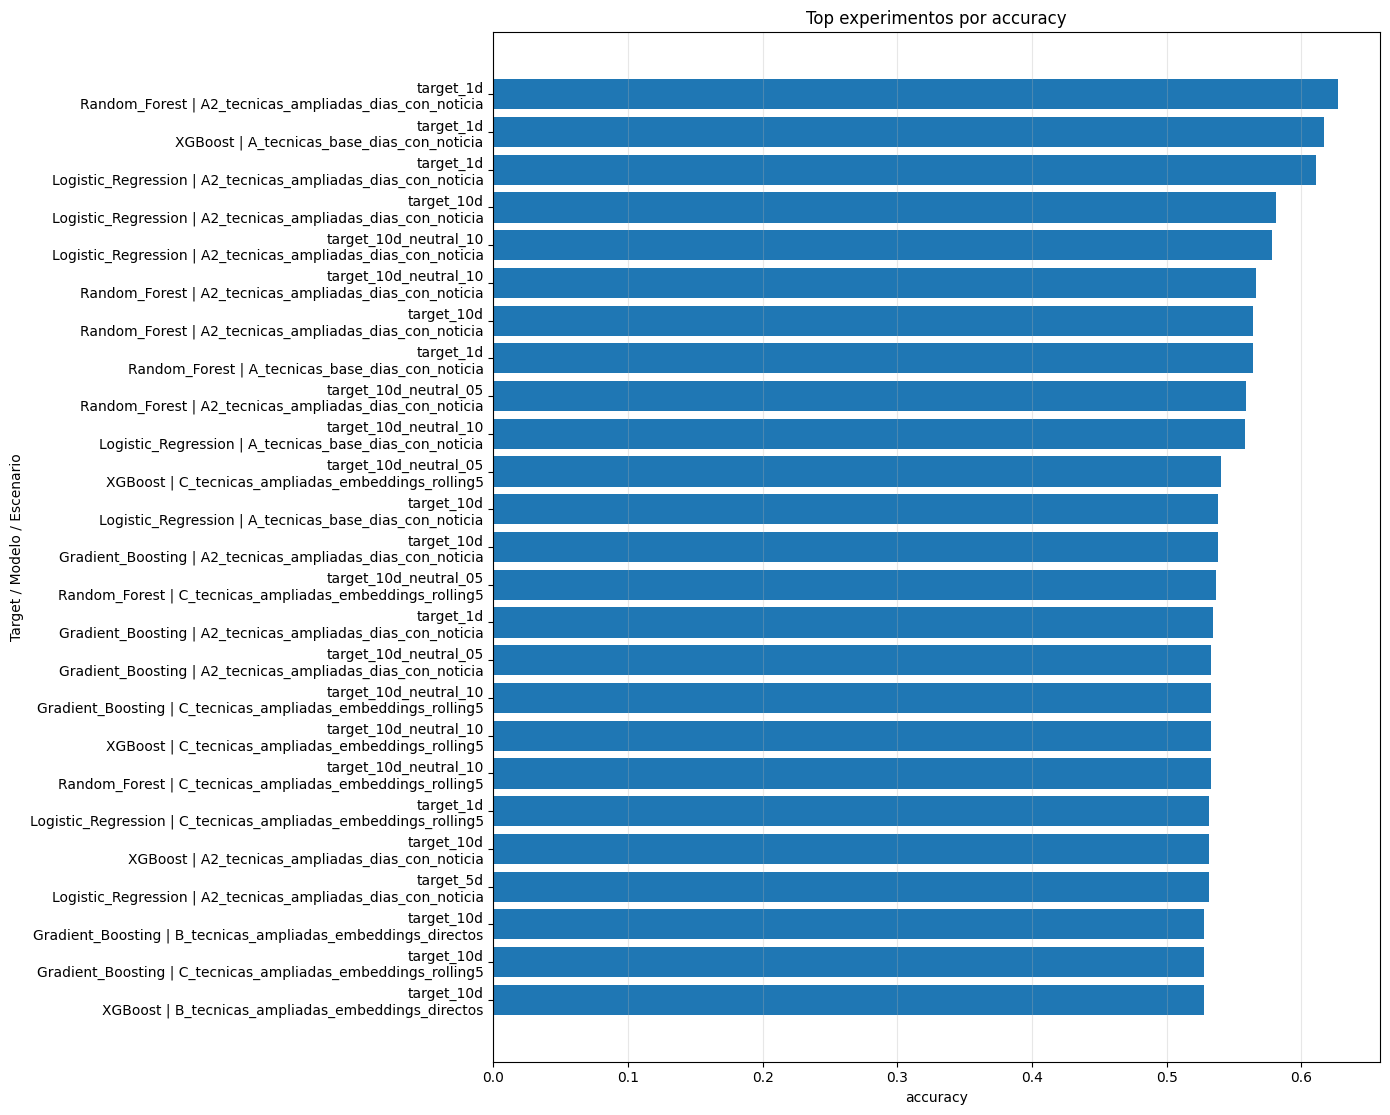

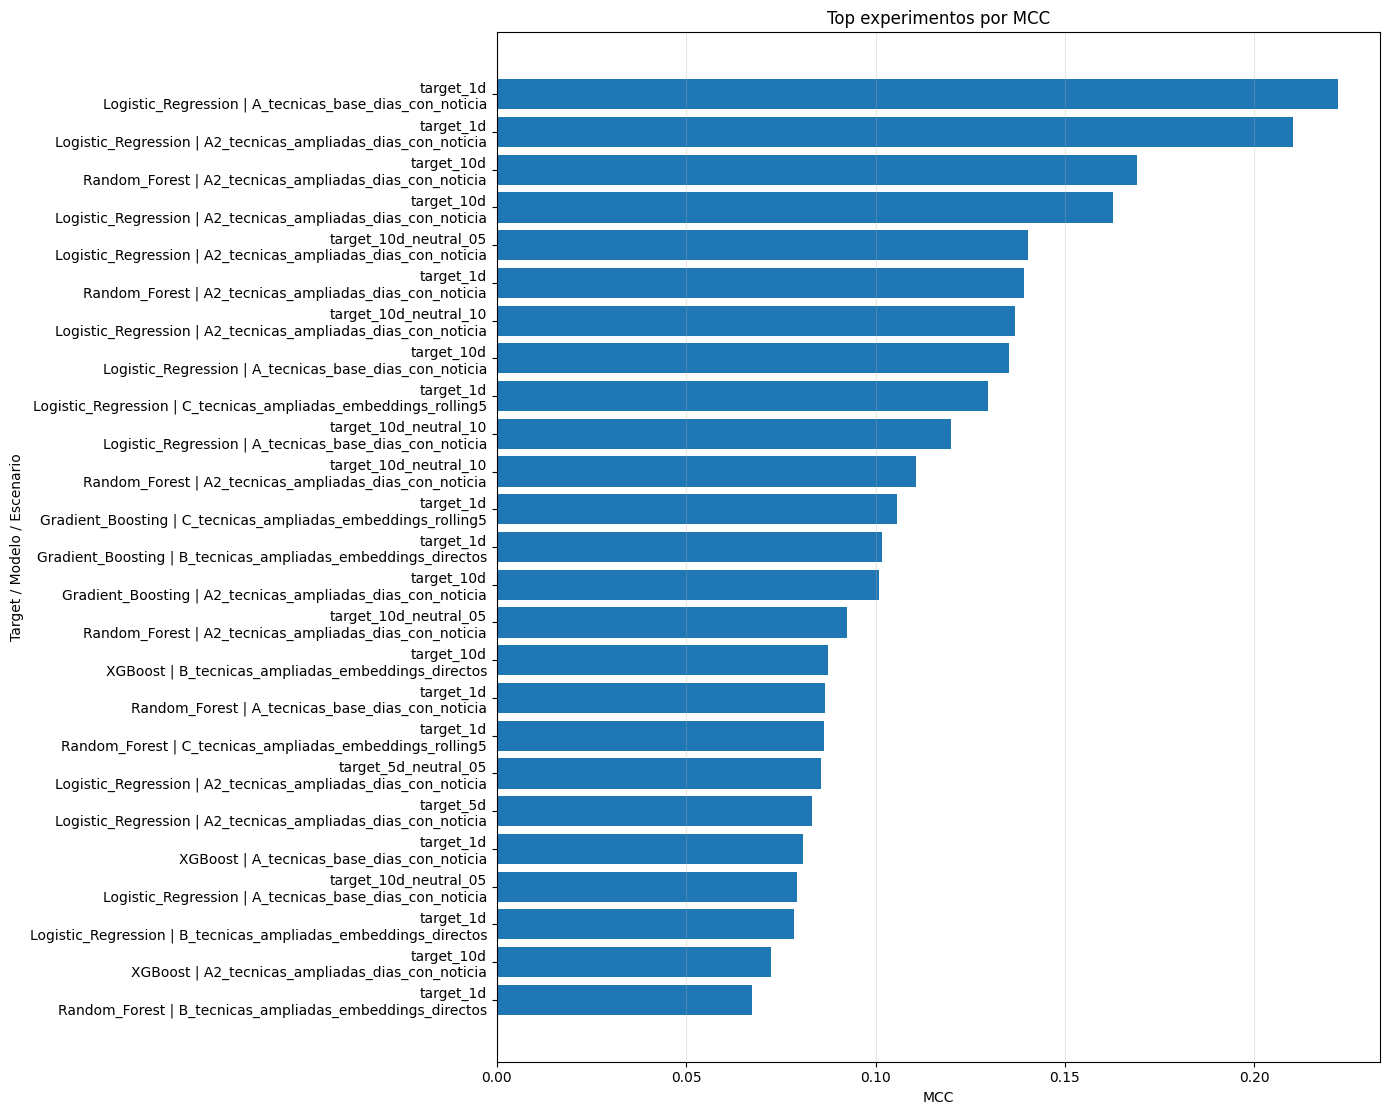

In [ ]:
# =========================================================
# Gráficas comparativas: top modelos por accuracy y MCC
# =========================================================

TOP_N_PLOT = 25

plot_df = ranking_accuracy.head(TOP_N_PLOT).copy()
plot_df["modelo_escenario"] = (
    plot_df["target_experiment"].astype(str)
    + "\n"
    + plot_df["modelo"].astype(str)
    + " | "
    + plot_df["escenario"].astype(str)
)

plt.figure(figsize=(14, max(7, 0.45 * len(plot_df))))
plt.barh(plot_df["modelo_escenario"][::-1], plot_df["accuracy"][::-1])
plt.xlabel("accuracy")
plt.ylabel("Target / Modelo / Escenario")
plt.title("Top experimentos por accuracy")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

plot_df = ranking_mcc.head(TOP_N_PLOT).copy()
plot_df["modelo_escenario"] = (
    plot_df["target_experiment"].astype(str)
    + "\n"
    + plot_df["modelo"].astype(str)
    + " | "
    + plot_df["escenario"].astype(str)
)

plt.figure(figsize=(14, max(7, 0.45 * len(plot_df))))
plt.barh(plot_df["modelo_escenario"][::-1], plot_df["mcc"][::-1])
plt.xlabel("MCC")
plt.ylabel("Target / Modelo / Escenario")
plt.title("Top experimentos por MCC")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# =========================================================
# Evaluación final en test 2025 de los top modelos
# =========================================================
# Este bloque reentrena cada configuración con train + validation
# y evalúa en 2025. Así se valida si el buen desempeño de validación
# se sostiene en un periodo verdaderamente fuera de muestra.
# =========================================================

TOP_K = 10
SELECTION_METRIC = "mcc"  # opciones sugeridas: "mcc", "accuracy", "balanced_accuracy"

top_configs = (
    experimental_results_df
    .sort_values(SELECTION_METRIC, ascending=False)
    .head(TOP_K)
    .copy()
)

test_top_results = []

def _safe_predict_proba_or_score(pipe, X):
    if hasattr(pipe.named_steps["model"], "predict_proba"):
        return pipe.predict_proba(X)[:, 1]
    return pipe.predict(X)

for _, row in top_configs.iterrows():

    target_exp = row["target_experiment"]
    target_col = row["target_col"]
    model_name = row["modelo"]
    scenario_name = row["escenario"]
    threshold = row["threshold"]

    features = SCENARIOS_EXPERIMENTAL[scenario_name]
    features = [c for c in features if c in dataset.columns]

    best_dataset, train_exp, val_exp, test_exp = prepare_target_dataset(
        dataset=dataset,
        target_col=target_col,
        val_start=VAL_START,
        test_start=TEST_START,
        test_end=TEST_END,
        features_to_check=features
    )

    train_full_exp = best_dataset[
        best_dataset["fecha"] < pd.to_datetime(TEST_START)
    ].copy()

    test_final_exp = best_dataset[
        (best_dataset["fecha"] >= pd.to_datetime(TEST_START)) &
        (best_dataset["fecha"] <= pd.to_datetime(TEST_END))
    ].copy()

    if len(train_full_exp) == 0 or len(test_final_exp) == 0:
        continue

    if train_full_exp["target_model"].nunique() < 2:
        continue

    X_train_full = train_full_exp[features]
    y_train_full = train_full_exp["target_model"]

    X_test = test_final_exp[features]
    y_test = test_final_exp["target_model"]

    model = get_classic_models()[model_name]

    pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train_full, y_train_full)

    y_prob_test = _safe_predict_proba_or_score(pipe, X_test)
    y_pred_test = (y_prob_test >= threshold).astype(int)

    metrics = compute_metrics(
        y_test,
        y_pred_test,
        y_prob_test
    )

    metrics.update({
        "target_experiment": target_exp,
        "target_col": target_col,
        "modelo": model_name,
        "escenario": scenario_name,
        "threshold_usado": threshold,
        "selection_metric": SELECTION_METRIC,
        "n_features": len(features),
        "n_train_full": len(train_full_exp),
        "n_test": len(test_final_exp),
        "test_class_0": int((y_test == 0).sum()),
        "test_class_1": int((y_test == 1).sum())
    })

    test_top_results.append(metrics)

test_top_results_df = pd.DataFrame(test_top_results)

print("\nResultados test 2025 para top modelos:")
if not test_top_results_df.empty:
    display(
        test_top_results_df
        .sort_values(["mcc", "balanced_accuracy", "accuracy"], ascending=False)
        .reset_index(drop=True)
    )
else:
    print("No se generaron resultados de test para los top modelos.")



Resultados test 2025 para top modelos:


,accuracy,balanced_accuracy,f1_score,mcc,roc_auc,target_experiment,target_col,modelo,escenario,threshold_usado,selection_metric,n_features,n_train_full,n_test,test_class_0,test_class_1
0,0.626016,0.570158,0.724551,0.148054,0.607027,target_10d_neutral_10,target_10d_neutral_10,Logistic_Regression,A2_tecnicas_ampliadas_dias_con_noticia,0.36,mcc,35,1085,246,87,159
1,0.557276,0.565072,0.565350,0.130737,0.575010,target_1d,target_1d,Logistic_Regression,C_tecnicas_ampliadas_embeddings_rolling5,0.30,mcc,816,1302,323,178,145
2,0.544892,0.556393,0.568915,0.114847,0.583456,target_1d,target_1d,Logistic_Regression,A_tecnicas_base_dias_con_noticia,0.38,mcc,9,1302,323,178,145
3,0.557276,0.538861,0.421053,0.083165,0.567609,target_1d,target_1d,Logistic_Regression,A2_tecnicas_ampliadas_dias_con_noticia,0.44,mcc,35,1302,323,178,145
4,0.554180,0.535579,0.628866,0.072278,0.550512,target_10d,target_10d,Logistic_Regression,A2_tecnicas_ampliadas_dias_con_noticia,0.43,mcc,35,1302,323,135,188
5,0.427562,0.523452,0.235849,0.068958,0.587624,target_10d_neutral_05,target_10d_neutral_05,Logistic_Regression,A2_tecnicas_ampliadas_dias_con_noticia,0.65,mcc,35,1185,283,106,177
6,0.572755,0.499330,0.720648,-0.002959,0.478369,target_10d,target_10d,Logistic_Regression,A_tecnicas_base_dias_con_noticia,0.31,mcc,9,1302,323,135,188
7,0.547988,0.497830,0.013514,-0.022500,0.575126,target_1d,target_1d,Random_Forest,A2_tecnicas_ampliadas_dias_con_noticia,0.59,mcc,35,1302,323,178,145
8,0.532508,0.489815,0.651270,-0.023475,0.493972,target_10d,target_10d,Random_Forest,A2_tecnicas_ampliadas_dias_con_noticia,0.33,mcc,35,1302,323,135,188
9,0.626016,0.486879,0.768844,-0.075457,0.598424,target_10d_neutral_10,target_10d_neutral_10,Logistic_Regression,A_tecnicas_base_dias_con_noticia,0.30,mcc,9,1085,246,87,159


# Deep learning

## 12 - Conf CNN y LSTM

In [ ]:
class StockSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def build_sequences(df, features, lookback=20):
    """
    Construye secuencias por stock.
    Cada muestra usa los últimos lookback días para predecir target del día actual.
    """
    X_list = []
    y_list = []
    meta_list = []

    df = df.sort_values(["stock", "fecha"]).copy()

    for stock, g in df.groupby("stock"):
        g = g.sort_values("fecha").reset_index(drop=True)

        X_values = g[features].values
        y_values = g["target"].values
        fechas = g["fecha"].values

        for i in range(lookback, len(g)):
            X_list.append(X_values[i - lookback:i])
            y_list.append(y_values[i])
            meta_list.append({
                "fecha": fechas[i],
                "stock": stock
            })

    X = np.array(X_list)
    y = np.array(y_list)
    meta = pd.DataFrame(meta_list)

    return X, y, meta


def scale_sequence_data(X_train, X_val, X_test=None):
    """
    Escala datos secuenciales usando solo información de entrenamiento.
    """
    n_train, t, f = X_train.shape

    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, f))

    X_train_scaled = scaler.transform(X_train.reshape(-1, f)).reshape(X_train.shape)
    X_val_scaled = scaler.transform(X_val.reshape(-1, f)).reshape(X_val.shape)

    if X_test is not None:
        X_test_scaled = scaler.transform(X_test.reshape(-1, f)).reshape(X_test.shape)
        return X_train_scaled, X_val_scaled, X_test_scaled, scaler

    return X_train_scaled, X_val_scaled, scaler

## 13 - Modelos CNN y LSTM

In [ ]:
class CNN1DClassifier(nn.Module):
    def __init__(self, n_features, hidden_channels=64, dropout=0.25):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv1d(in_channels=n_features, out_channels=hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_channels),
            nn.Dropout(dropout),

            nn.Conv1d(in_channels=hidden_channels, out_channels=hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_channels),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_channels, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: batch, time, features
        x = x.permute(0, 2, 1)
        x = self.net(x)
        logits = self.classifier(x).squeeze(1)
        return logits


class LSTMClassifier(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=1, dropout=0.25):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0 if num_layers == 1 else dropout
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        logits = self.classifier(last_hidden).squeeze(1)
        return logits


def train_torch_model(model, train_loader, val_loader, epochs=25, lr=1e-3, patience=5):
    model = model.to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    best_val_loss = np.inf
    best_state = None
    patience_counter = 0

    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        all_probs = []
        all_true = []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)

                logits = model(X_batch)
                loss = criterion(logits, y_batch)

                probs = torch.sigmoid(logits).detach().cpu().numpy()

                val_losses.append(loss.item())
                all_probs.extend(probs)
                all_true.extend(y_batch.detach().cpu().numpy())

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)

        y_prob = np.array(all_probs)
        y_true = np.array(all_true).astype(int)

        thr, _ = find_best_threshold(y_true, y_prob, metric="mcc")
        y_pred = (y_prob >= thr).astype(int)
        mcc = matthews_corrcoef(y_true, y_pred)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_mcc": mcc,
            "threshold": thr
        })

        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val MCC: {mcc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping activado.")
            break

    model.load_state_dict(best_state)

    return model, pd.DataFrame(history)


def predict_torch_model(model, loader):
    model.eval()
    probs = []
    y_true = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)

            logits = model(X_batch)
            batch_probs = torch.sigmoid(logits).detach().cpu().numpy()

            probs.extend(batch_probs)
            y_true.extend(y_batch.numpy())

    return np.array(y_true).astype(int), np.array(probs)

## 14 - Trainin DL

In [ ]:
# =========================================================
# 14 - Modelos Deep Learning corregidos y robustos
# =========================================================
# Objetivo:
#   - Entrenar CNN1D y LSTM evitando errores por NaN/inf.
#   - Limpiar features antes de construir secuencias.
#   - Evitar fallo cuando best_state queda como None.
#   - Usar gradient clipping para mayor estabilidad.
# =========================================================

import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import matthews_corrcoef


# =========================================================
# 14.1 - Limpieza de features para deep learning
# =========================================================

def clean_features_for_deep_learning(df, features):
    """
    Limpia NaN, inf y -inf en las features usadas por CNN/LSTM.

    Estrategia:
        1. Convertir features a numérico.
        2. Reemplazar inf/-inf por NaN.
        3. Imputar por mediana dentro de cada stock.
        4. Imputar por mediana global.
        5. Si aún quedan NaN, rellenar con 0.
    """

    df = df.copy()

    valid_features = [c for c in features if c in df.columns]

    for c in valid_features:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df[valid_features] = df[valid_features].replace(
        [np.inf, -np.inf],
        np.nan
    )

    for c in valid_features:
        df[c] = (
            df.groupby("stock")[c]
            .transform(lambda x: x.fillna(x.median()))
        )

        df[c] = df[c].fillna(df[c].median())
        df[c] = df[c].fillna(0)

    return df


# =========================================================
# 14.2 - Dataset para secuencias
# =========================================================

class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# =========================================================
# 14.3 - Construcción robusta de secuencias
# =========================================================

def build_sequences(df, features, lookback=20, target_col="target"):
    """
    Construye secuencias temporales por stock.

    Cada observación X contiene los últimos `lookback` registros
    disponibles de ese stock.

    Seguridad:
        - Convierte features a float32.
        - Reemplaza NaN/inf por 0.
        - Omite targets NaN.
    """

    X = []
    y = []
    meta = []

    df = df.copy()
    df = df.sort_values(["stock", "fecha"]).reset_index(drop=True)

    valid_features = [c for c in features if c in df.columns]

    if len(valid_features) == 0:
        raise ValueError("No hay features válidas para construir secuencias.")

    for stock, group in df.groupby("stock"):

        group = group.sort_values("fecha").reset_index(drop=True)

        if len(group) <= lookback:
            continue

        for i in range(lookback, len(group)):

            target_value = group.iloc[i][target_col]

            if pd.isna(target_value):
                continue

            seq_values = (
                group.iloc[i - lookback:i][valid_features]
                .values
                .astype(np.float32)
            )

            seq_values = np.nan_to_num(
                seq_values,
                nan=0.0,
                posinf=0.0,
                neginf=0.0
            )

            X.append(seq_values)
            y.append(int(target_value))

            meta.append({
                "fecha": group.iloc[i]["fecha"],
                "stock": stock
            })

    if len(X) == 0:
        return (
            np.empty((0, lookback, len(valid_features)), dtype=np.float32),
            np.array([], dtype=np.float32),
            pd.DataFrame(meta)
        )

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    return X, y, pd.DataFrame(meta)


# =========================================================
# 14.4 - Escalamiento de secuencias
# =========================================================

def scale_sequence_data(X_train, X_val):
    """
    Escala secuencias usando StandardScaler ajustado solo con train.
    Evita data leakage.
    """

    if len(X_train) == 0 or len(X_val) == 0:
        return X_train, X_val, None

    n_train, lookback, n_features = X_train.shape
    n_val = X_val.shape[0]

    scaler = StandardScaler()

    X_train_2d = X_train.reshape(-1, n_features)
    X_val_2d = X_val.reshape(-1, n_features)

    X_train_2d = np.nan_to_num(
        X_train_2d,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    X_val_2d = np.nan_to_num(
        X_val_2d,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    X_train_scaled = scaler.fit_transform(X_train_2d)
    X_val_scaled = scaler.transform(X_val_2d)

    X_train_scaled = np.nan_to_num(
        X_train_scaled,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    X_val_scaled = np.nan_to_num(
        X_val_scaled,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    X_train_scaled = X_train_scaled.reshape(n_train, lookback, n_features)
    X_val_scaled = X_val_scaled.reshape(n_val, lookback, n_features)

    return X_train_scaled, X_val_scaled, scaler


# =========================================================
# 14.5 - Modelos CNN1D y LSTM
# =========================================================

class CNN1DClassifier(nn.Module):
    def __init__(self, n_features, hidden_channels=64, dropout=0.30):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv1d(
                in_channels=n_features,
                out_channels=hidden_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm1d(hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(
                in_channels=hidden_channels,
                out_channels=hidden_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm1d(hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_channels, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: batch, lookback, features
        x = x.permute(0, 2, 1)
        x = self.net(x)
        x = x.squeeze(-1)
        x = self.classifier(x)
        return x


class LSTMClassifier(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=1, dropout=0.30):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0 if num_layers == 1 else dropout
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        output, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]
        return self.classifier(last_hidden)


# =========================================================
# 14.6 - Entrenamiento robusto
# =========================================================

def train_deep_model(
    model,
    train_loader,
    val_loader,
    epochs=30,
    lr=1e-3,
    patience=5
):
    """
    Entrena un modelo deep learning evitando fallos cuando:
        - la loss es NaN
        - las probabilidades tienen NaN/inf
        - no se alcanza a guardar best_state
    """

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=1e-5
    )

    best_mcc = -np.inf
    best_state = None
    patience_counter = 0

    history = []

    for epoch in range(1, epochs + 1):

        # -------------------------
        # Train
        # -------------------------

        model.train()
        train_losses = []

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device).float()
            y_batch = y_batch.to(device).float()

            X_batch = torch.nan_to_num(
                X_batch,
                nan=0.0,
                posinf=0.0,
                neginf=0.0
            )

            y_batch = torch.nan_to_num(
                y_batch,
                nan=0.0,
                posinf=1.0,
                neginf=0.0
            )

            optimizer.zero_grad()

            y_prob = model(X_batch).view(-1)

            y_prob = torch.nan_to_num(
                y_prob,
                nan=0.5,
                posinf=1.0,
                neginf=0.0
            )

            y_prob = torch.clamp(y_prob, 1e-6, 1 - 1e-6)

            loss = criterion(y_prob, y_batch)

            if torch.isnan(loss) or torch.isinf(loss):
                continue

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            train_losses.append(loss.item())

        train_loss = (
            float(np.mean(train_losses))
            if len(train_losses) > 0
            else np.nan
        )

        # -------------------------
        # Validation
        # -------------------------

        model.eval()

        val_losses = []
        y_true_all = []
        y_prob_all = []

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(device).float()
                y_batch = y_batch.to(device).float()

                X_batch = torch.nan_to_num(
                    X_batch,
                    nan=0.0,
                    posinf=0.0,
                    neginf=0.0
                )

                y_batch = torch.nan_to_num(
                    y_batch,
                    nan=0.0,
                    posinf=1.0,
                    neginf=0.0
                )

                y_prob = model(X_batch).view(-1)

                y_prob = torch.nan_to_num(
                    y_prob,
                    nan=0.5,
                    posinf=1.0,
                    neginf=0.0
                )

                y_prob = torch.clamp(y_prob, 1e-6, 1 - 1e-6)

                loss = criterion(y_prob, y_batch)

                if not torch.isnan(loss) and not torch.isinf(loss):
                    val_losses.append(loss.item())

                y_true_all.extend(y_batch.cpu().numpy())
                y_prob_all.extend(y_prob.cpu().numpy())

        val_loss = (
            float(np.mean(val_losses))
            if len(val_losses) > 0
            else np.nan
        )

        y_true_all = np.array(y_true_all).astype(int)

        y_prob_all = np.array(y_prob_all)
        y_prob_all = np.nan_to_num(
            y_prob_all,
            nan=0.5,
            posinf=1.0,
            neginf=0.0
        )

        y_pred_all = (y_prob_all >= 0.5).astype(int)

        if len(np.unique(y_true_all)) < 2:
            val_mcc = 0.0
        else:
            val_mcc = matthews_corrcoef(y_true_all, y_pred_all)

        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val MCC: {val_mcc:.4f}"
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_mcc": val_mcc
        })

        if not np.isnan(val_mcc) and val_mcc > best_mcc:
            best_mcc = val_mcc

            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

            patience_counter = 0

        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping activado.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    else:
        print(
            "Advertencia: no se encontró best_state válido. "
            "Se conserva el último estado del modelo."
        )

    return model, pd.DataFrame(history)


# =========================================================
# 14.7 - Predicción deep learning
# =========================================================

def predict_deep_model(model, loader):
    """
    Genera probabilidades para un modelo deep learning.
    """

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    y_true_all = []
    y_prob_all = []

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device).float()
            y_batch = y_batch.to(device).float()

            X_batch = torch.nan_to_num(
                X_batch,
                nan=0.0,
                posinf=0.0,
                neginf=0.0
            )

            y_prob = model(X_batch).view(-1)

            y_prob = torch.nan_to_num(
                y_prob,
                nan=0.5,
                posinf=1.0,
                neginf=0.0
            )

            y_prob = torch.clamp(y_prob, 1e-6, 1 - 1e-6)

            y_true_all.extend(y_batch.cpu().numpy())
            y_prob_all.extend(y_prob.cpu().numpy())

    y_true_all = np.array(y_true_all).astype(int)

    y_prob_all = np.array(y_prob_all)
    y_prob_all = np.nan_to_num(
        y_prob_all,
        nan=0.5,
        posinf=1.0,
        neginf=0.0
    )

    return y_true_all, y_prob_all


# =========================================================
# 14.8 - Función principal de entrenamiento deep learning
# =========================================================

def train_evaluate_deep_models(
    train_df,
    val_df,
    scenario_name,
    features,
    target_col="target",
    lookback=20,
    batch_size=32,
    epochs=30,
    lr=1e-3,
    patience=5
):
    """
    Entrena CNN1D y LSTM para un escenario de features dado.
    """

    print(f"\nEntrenando modelos deep learning para escenario: {scenario_name}")

    valid_features = [c for c in features if c in train_df.columns]

    if len(valid_features) == 0:
        raise ValueError("No hay features válidas para deep learning.")

    # -----------------------------------------------------
    # Limpieza previa
    # -----------------------------------------------------

    train_clean = clean_features_for_deep_learning(
        train_df,
        valid_features
    )

    val_clean = clean_features_for_deep_learning(
        val_df,
        valid_features
    )

    print(
        "NaN train deep:",
        train_clean[valid_features].isna().sum().sum()
    )

    print(
        "NaN val deep:",
        val_clean[valid_features].isna().sum().sum()
    )

    print(
        "Inf train deep:",
        np.isinf(train_clean[valid_features].values).sum()
    )

    print(
        "Inf val deep:",
        np.isinf(val_clean[valid_features].values).sum()
    )

    # -----------------------------------------------------
    # Construcción de secuencias
    # -----------------------------------------------------

    X_train_seq, y_train_seq, meta_train = build_sequences(
        train_clean,
        valid_features,
        lookback=lookback,
        target_col=target_col
    )

    X_val_seq, y_val_seq, meta_val = build_sequences(
        val_clean,
        valid_features,
        lookback=lookback,
        target_col=target_col
    )

    if len(X_train_seq) == 0 or len(X_val_seq) == 0:
        print(
            f"No hay suficientes secuencias para entrenar deep learning "
            f"en el escenario {scenario_name}. "
            f"Train seq: {len(X_train_seq)}, Val seq: {len(X_val_seq)}"
        )

        return pd.DataFrame(), {}

    print("X_train_seq:", X_train_seq.shape)
    print("X_val_seq:", X_val_seq.shape)

    # -----------------------------------------------------
    # Escalamiento
    # -----------------------------------------------------

    X_train_seq, X_val_seq, seq_scaler = scale_sequence_data(
        X_train_seq,
        X_val_seq
    )

    # -----------------------------------------------------
    # Validación final
    # -----------------------------------------------------

    print("NaN X_train_seq:", np.isnan(X_train_seq).sum())
    print("NaN X_val_seq:", np.isnan(X_val_seq).sum())
    print("Inf X_train_seq:", np.isinf(X_train_seq).sum())
    print("Inf X_val_seq:", np.isinf(X_val_seq).sum())

    # -----------------------------------------------------
    # DataLoaders
    # -----------------------------------------------------

    train_dataset = SequenceDataset(
        X_train_seq,
        y_train_seq
    )

    val_dataset = SequenceDataset(
        X_val_seq,
        y_val_seq
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    n_features = X_train_seq.shape[-1]

    model_factories = {
        "CNN1D": lambda: CNN1DClassifier(
            n_features=n_features,
            hidden_channels=64,
            dropout=0.30
        ),
        "LSTM": lambda: LSTMClassifier(
            n_features=n_features,
            hidden_size=64,
            num_layers=1,
            dropout=0.30
        )
    }

    results = []
    trained_models = {}

    # -----------------------------------------------------
    # Entrenar modelos
    # -----------------------------------------------------

    for model_name, model_factory in model_factories.items():

        print("\n" + "=" * 30)
        print(f"Modelo deep: {model_name}")
        print("=" * 30)

        torch.manual_seed(42)
        np.random.seed(42)

        model = model_factory()

        model, history = train_deep_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=epochs,
            lr=lr,
            patience=patience
        )

        y_true, y_prob = predict_deep_model(
            model,
            val_loader
        )

        best_thr, _ = find_best_threshold(
            y_true,
            y_prob,
            metric="mcc"
        )

        y_pred = (y_prob >= best_thr).astype(int)

        metrics = compute_metrics(
            y_true,
            y_pred,
            y_prob
        )

        metrics.update({
            "modelo": model_name,
            "escenario": scenario_name,
            "threshold": best_thr,
            "n_features": n_features,
            "lookback": lookback,
            "n_train_seq": len(X_train_seq),
            "n_val_seq": len(X_val_seq),
            "tipo_modelo": "Deep_Learning"
        })

        results.append(metrics)

        trained_models[model_name] = {
            "model": model,
            "history": history,
            "scaler": seq_scaler,
            "features": valid_features,
            "lookback": lookback
        }

    results_df = pd.DataFrame(results)

    return results_df, trained_models


# =========================================================
# 14.9 - Ejecución del escenario deep learning
# =========================================================
# Puedes cambiar el escenario si quieres probar uno más liviano.
#
# Opción pesada:
#   C_tecnicas_ampliadas_embeddings_rolling5
#
# Opción más estable:
#   A2_tecnicas_ampliadas_dias_con_noticia
# =========================================================

DEEP_SCENARIO_NAME = "C_tecnicas_ampliadas_embeddings_rolling5"
DEEP_FEATURES = SCENARIOS_EXPERIMENTAL[DEEP_SCENARIO_NAME]

# Parámetros recomendados
LOOKBACK_DAYS_DL = 20
BATCH_SIZE_DL = 32
EPOCHS_DL_SAFE = 30
LEARNING_RATE_DL_SAFE = 1e-3
PATIENCE_DL_SAFE = 5

deep_results_df, deep_models = train_evaluate_deep_models(
    train_df=train_df,
    val_df=val_df,
    scenario_name=DEEP_SCENARIO_NAME,
    features=DEEP_FEATURES,
    target_col="target",
    lookback=LOOKBACK_DAYS_DL,
    batch_size=BATCH_SIZE_DL,
    epochs=EPOCHS_DL_SAFE,
    lr=LEARNING_RATE_DL_SAFE,
    patience=PATIENCE_DL_SAFE
)

print("\nResultados deep learning:")
display(deep_results_df)


Entrenando modelos deep learning para escenario: C_tecnicas_ampliadas_embeddings_rolling5
NaN train deep: 0
NaN val deep: 0
Inf train deep: 0
Inf val deep: 0
X_train_seq: (919, 20, 816)
X_val_seq: (223, 20, 816)
NaN X_train_seq: 0
NaN X_val_seq: 0
Inf X_train_seq: 0
Inf X_val_seq: 0

Modelo deep: CNN1D
Epoch 01 | Train Loss: 0.6930 | Val Loss: 0.6746 | Val MCC: 0.1094
Epoch 02 | Train Loss: 0.6857 | Val Loss: 0.6762 | Val MCC: -0.0217
Epoch 03 | Train Loss: 0.6863 | Val Loss: 0.6630 | Val MCC: 0.0000
Epoch 04 | Train Loss: 0.6865 | Val Loss: 0.6678 | Val MCC: 0.0109
Epoch 05 | Train Loss: 0.6828 | Val Loss: 0.6665 | Val MCC: 0.0919
Epoch 06 | Train Loss: 0.6802 | Val Loss: 0.6685 | Val MCC: 0.0393
Early stopping activado.

Modelo deep: LSTM
Epoch 01 | Train Loss: 0.6911 | Val Loss: 0.6708 | Val MCC: 0.1081
Epoch 02 | Train Loss: 0.6758 | Val Loss: 0.6777 | Val MCC: 0.0406
Epoch 03 | Train Loss: 0.6696 | Val Loss: 0.6714 | Val MCC: 0.0959
Epoch 04 | Train Loss: 0.6616 | Val Loss: 0.670

,accuracy,balanced_accuracy,f1_score,mcc,roc_auc,modelo,escenario,threshold,n_features,lookback,n_train_seq,n_val_seq,tipo_modelo
0,0.439462,0.528279,0.587459,0.134076,0.584712,CNN1D,C_tecnicas_ampliadas_embeddings_rolling5,0.37,816,20,919,223,Deep_Learning
1,0.502242,0.571930,0.602151,0.196343,0.575773,LSTM,C_tecnicas_ampliadas_embeddings_rolling5,0.40,816,20,919,223,Deep_Learning


## 15 - GNN + LSTM

Stocks grafo: ['ARG', 'CIBEST', 'EC', 'NCH']


stock,ARG,CIBEST,EC,NCH
stock,,,,
ARG,1.000000,0.356456,0.283105,-0.166257
CIBEST,0.356456,1.000000,0.340811,-0.058614
EC,0.283105,0.340811,1.000000,0.016186
NCH,-0.166257,-0.058614,0.016186,1.000000


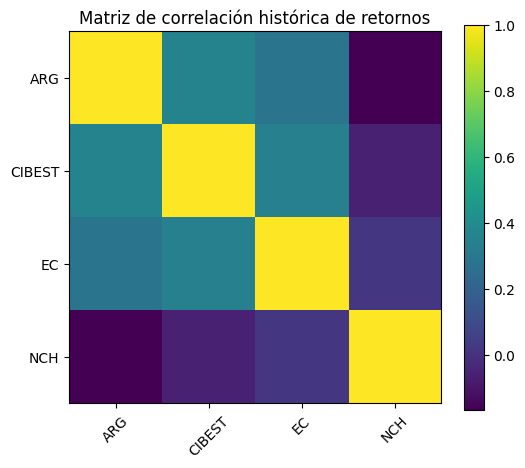

In [ ]:
def build_correlation_adjacency(df, threshold=0.20):
    """
    Construye matriz de adyacencia usando correlación histórica de retornos.
    """
    pivot_returns = df.pivot_table(
        index="fecha",
        columns="stock",
        values="return_1d"
    ).sort_index()

    corr = pivot_returns.corr().fillna(0)

    stocks = corr.columns.tolist()

    adj = corr.abs().values

    # Eliminar conexiones débiles
    adj = np.where(adj >= threshold, adj, 0)

    # Mantener autoconexiones
    np.fill_diagonal(adj, 1)

    # Normalización simétrica A_hat = D^-1/2 A D^-1/2
    degree = adj.sum(axis=1)
    degree_inv_sqrt = np.diag(1.0 / np.sqrt(degree + 1e-8))
    adj_norm = degree_inv_sqrt @ adj @ degree_inv_sqrt

    return stocks, corr, adj_norm


stocks_graph, corr_matrix, adj_norm = build_correlation_adjacency(
    train_df,
    threshold=0.20
)

print("Stocks grafo:", stocks_graph)
display(corr_matrix)

plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix.values)
plt.colorbar()
plt.xticks(range(len(stocks_graph)), stocks_graph, rotation=45)
plt.yticks(range(len(stocks_graph)), stocks_graph)
plt.title("Matriz de correlación histórica de retornos")
plt.show()

## 16 - Dataset para GNN

In [ ]:
def build_panel_tensor(df, features, stocks_order):
    """
    Construye panel temporal:
    fechas x stocks x features.
    """
    df = df.copy()
    df = df[df["stock"].isin(stocks_order)]

    dates = sorted(df["fecha"].unique())

    X_list = []
    y_list = []
    valid_dates = []

    for fecha in dates:
        day = df[df["fecha"] == fecha].set_index("stock")

        if not all(stock in day.index for stock in stocks_order):
            continue

        X_day = day.loc[stocks_order, features].values
        y_day = day.loc[stocks_order, "target"].values

        X_list.append(X_day)
        y_list.append(y_day)
        valid_dates.append(fecha)

    X_panel = np.array(X_list)
    y_panel = np.array(y_list)
    valid_dates = pd.to_datetime(valid_dates)

    return X_panel, y_panel, valid_dates


def build_gnn_sequences(df, features, stocks_order, lookback=20):
    X_panel, y_panel, dates = build_panel_tensor(df, features, stocks_order)

    X_seq = []
    y_seq = []
    date_seq = []

    for i in range(lookback, len(dates)):
        X_seq.append(X_panel[i - lookback:i])
        y_seq.append(y_panel[i])
        date_seq.append(dates[i])

    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq)
    date_seq = pd.to_datetime(date_seq)

    return X_seq, y_seq, date_seq


class GNNSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def scale_gnn_data(X_train, X_val):
    """
    X shape: samples, lookback, nodes, features.
    """
    n, t, nodes, f = X_train.shape

    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, f))

    X_train_scaled = scaler.transform(X_train.reshape(-1, f)).reshape(X_train.shape)
    X_val_scaled = scaler.transform(X_val.reshape(-1, f)).reshape(X_val.shape)

    return X_train_scaled, X_val_scaled, scaler

## 17 - Building GNN + LSTM

In [ ]:
class ManualGraphConv(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x, adj):
        """
        x: batch, nodes, features
        adj: nodes, nodes
        """
        x_graph = torch.einsum("ij,bjf->bif", adj, x)
        return self.linear(x_graph)


class GNNLSTMClassifier(nn.Module):
    def __init__(self, n_features, n_nodes, adj_matrix, gnn_hidden=32, lstm_hidden=64, dropout=0.25):
        super().__init__()

        self.register_buffer(
            "adj",
            torch.tensor(adj_matrix, dtype=torch.float32)
        )

        self.gcn = ManualGraphConv(n_features, gnn_hidden)

        self.lstm = nn.LSTM(
            input_size=gnn_hidden,
            hidden_size=lstm_hidden,
            batch_first=True
        )

        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

        self.n_nodes = n_nodes

    def forward(self, x):
        """
        x: batch, lookback, nodes, features
        output: batch, nodes
        """
        batch_size, lookback, n_nodes, n_features = x.shape

        node_outputs = []

        for node_idx in range(n_nodes):
            node_seq = []

            for t in range(lookback):
                x_t = x[:, t, :, :]               # batch, nodes, features
                h_t = torch.relu(self.gcn(x_t, self.adj))  # batch, nodes, gnn_hidden
                node_seq.append(h_t[:, node_idx, :])

            node_seq = torch.stack(node_seq, dim=1)  # batch, lookback, gnn_hidden

            lstm_out, _ = self.lstm(node_seq)
            last_hidden = lstm_out[:, -1, :]

            logit = self.classifier(last_hidden).squeeze(1)
            node_outputs.append(logit)

        logits = torch.stack(node_outputs, dim=1)  # batch, nodes
        return logits


def train_gnn_lstm(model, train_loader, val_loader, epochs=25, lr=1e-3, patience=5):
    model = model.to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    best_val_loss = np.inf
    best_state = None
    patience_counter = 0

    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        probs_all = []
        true_all = []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)

                logits = model(X_batch)
                loss = criterion(logits, y_batch)

                probs = torch.sigmoid(logits).detach().cpu().numpy()

                val_losses.append(loss.item())
                probs_all.extend(probs.reshape(-1))
                true_all.extend(y_batch.detach().cpu().numpy().reshape(-1))

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)

        y_prob = np.array(probs_all)
        y_true = np.array(true_all).astype(int)

        thr, _ = find_best_threshold(y_true, y_prob, metric="mcc")
        y_pred = (y_prob >= thr).astype(int)
        mcc = matthews_corrcoef(y_true, y_pred)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_mcc": mcc,
            "threshold": thr
        })

        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val MCC: {mcc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping activado.")
            break

    model.load_state_dict(best_state)

    return model, pd.DataFrame(history)


def predict_gnn_lstm(model, loader):
    model.eval()

    probs_all = []
    true_all = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)

            logits = model(X_batch)
            probs = torch.sigmoid(logits).detach().cpu().numpy()

            probs_all.extend(probs.reshape(-1))
            true_all.extend(y_batch.numpy().reshape(-1))

    return np.array(true_all).astype(int), np.array(probs_all)

## 18 - Training GNN+LSTM

In [ ]:
# =========================================================
# 18 - Training GNN + LSTM
# =========================================================
# Se mantiene como prueba avanzada sobre el escenario rolling.
# Incluye validación para evitar errores si el filtro por noticias deja
# pocas fechas comunes entre acciones.
# =========================================================

X_train_gnn, y_train_gnn, dates_train_gnn = build_gnn_sequences(
    train_df,
    FEATURES_EMBEDDINGS_ROLLING,
    stocks_order=stocks_graph,
    lookback=LOOKBACK_DAYS
)

X_val_gnn, y_val_gnn, dates_val_gnn = build_gnn_sequences(
    val_df,
    FEATURES_EMBEDDINGS_ROLLING,
    stocks_order=stocks_graph,
    lookback=LOOKBACK_DAYS
)

print("X_train_gnn:", X_train_gnn.shape)
print("y_train_gnn:", y_train_gnn.shape)

print("X_val_gnn:", X_val_gnn.shape)
print("y_val_gnn:", y_val_gnn.shape)

if len(X_train_gnn) == 0 or len(X_val_gnn) == 0:
    print(
        "No hay suficientes secuencias para entrenar GNN-LSTM "
        "después de filtrar únicamente días con noticia."
    )
    gnn_results_df = pd.DataFrame()
    gnn_lstm_model = None
    gnn_history = []
else:
    X_train_gnn, X_val_gnn, gnn_scaler = scale_gnn_data(X_train_gnn, X_val_gnn)

    train_gnn_dataset = GNNSequenceDataset(X_train_gnn, y_train_gnn)
    val_gnn_dataset = GNNSequenceDataset(X_val_gnn, y_val_gnn)

    train_gnn_loader = DataLoader(train_gnn_dataset, batch_size=32, shuffle=True)
    val_gnn_loader = DataLoader(val_gnn_dataset, batch_size=32, shuffle=False)

    gnn_lstm_model = GNNLSTMClassifier(
        n_features=X_train_gnn.shape[-1],
        n_nodes=len(stocks_graph),
        adj_matrix=adj_norm,
        gnn_hidden=32,
        lstm_hidden=64,
        dropout=0.25
    )

    gnn_lstm_model, gnn_history = train_gnn_lstm(
        model=gnn_lstm_model,
        train_loader=train_gnn_loader,
        val_loader=val_gnn_loader,
        epochs=EPOCHS_DL,
        lr=LEARNING_RATE_DL,
        patience=PATIENCE_DL
    )

    y_true_gnn, y_prob_gnn = predict_gnn_lstm(gnn_lstm_model, val_gnn_loader)

    best_thr_gnn, _ = find_best_threshold(y_true_gnn, y_prob_gnn, metric="mcc")
    y_pred_gnn = (y_prob_gnn >= best_thr_gnn).astype(int)

    gnn_metrics = compute_metrics(y_true_gnn, y_pred_gnn, y_prob_gnn)
    gnn_metrics.update({
        "modelo": "GNN_LSTM",
        "escenario": "C_tecnicas_ampliadas_embeddings_rolling5",
        "threshold": best_thr_gnn,
        "n_features": len(FEATURES_EMBEDDINGS_ROLLING),
        "tipo_modelo": "GNN_Deep_Learning"
    })

    gnn_results_df = pd.DataFrame([gnn_metrics])
    display(gnn_results_df)


X_train_gnn: (0,)
y_train_gnn: (0,)
X_val_gnn: (0,)
y_val_gnn: (0,)
No hay suficientes secuencias para entrenar GNN-LSTM después de filtrar únicamente días con noticia.


# RESUMEN GENERAL MODELOS

## 19 - Resumen resultados

In [ ]:
# =========================================================
# 19 - Resumen resultados del flujo base
# =========================================================
# Esta sección resume modelos clásicos/deep/GNN del target base.
# Los experimentos de targets alternativos están en experimental_results_df.
# =========================================================

result_frames = []
for df_name in ["classic_results_df", "deep_results_df", "gnn_results_df"]:
    if df_name in globals():
        df_obj = globals()[df_name]
        if isinstance(df_obj, pd.DataFrame) and not df_obj.empty:
            result_frames.append(df_obj)

if len(result_frames) == 0:
    all_results_df = pd.DataFrame()
    print("No hay resultados base para consolidar.")
else:
    all_results_df = pd.concat(result_frames, ignore_index=True)

    all_results_df = all_results_df.sort_values(
        ["mcc", "accuracy"],
        ascending=False
    ).reset_index(drop=True)

    display(all_results_df)

    best_row = all_results_df.iloc[0]

    BEST_MODEL_NAME = best_row["modelo"]
    BEST_SCENARIO = best_row["escenario"]
    BEST_THRESHOLD = best_row["threshold"]
    BEST_MODEL_TYPE = best_row["tipo_modelo"]

    print("======================================")
    print("MEJOR MODELO EN VALIDACIÓN - FLUJO BASE")
    print("======================================")
    print("Modelo:", BEST_MODEL_NAME)
    print("Escenario:", BEST_SCENARIO)
    print("Tipo:", BEST_MODEL_TYPE)
    print("Threshold:", BEST_THRESHOLD)
    print("Accuracy:", best_row["accuracy"])
    print("MCC:", best_row["mcc"])

print("\nPara los experimentos de búsqueda de accuracy, revisar:")
print("- experimental_results_df")
print("- ranking_accuracy")
print("- ranking_mcc")
print("- test_top_results_df")


,accuracy,balanced_accuracy,f1_score,mcc,roc_auc,modelo,escenario,threshold,n_features,tipo_modelo,lookback,n_train_seq,n_val_seq
0,0.504950,0.583852,0.596774,0.222105,0.573317,Logistic_Regression,A_tecnicas_base_dias_con_noticia,0.38,9,Clasico,NaN,NaN,NaN
1,0.610561,0.607421,0.542636,0.210130,0.620110,Logistic_Regression,A2_tecnicas_ampliadas_dias_con_noticia,0.44,35,Clasico,NaN,NaN,NaN
2,0.502242,0.571930,0.602151,0.196343,0.575773,LSTM,C_tecnicas_ampliadas_embeddings_rolling5,0.40,816,Deep_Learning,20.0,919.0,223.0
3,0.627063,0.524256,0.110236,0.139339,0.540357,Random_Forest,A2_tecnicas_ampliadas_dias_con_noticia,0.59,35,Clasico,NaN,NaN,NaN
4,0.439462,0.528279,0.587459,0.134076,0.584712,CNN1D,C_tecnicas_ampliadas_embeddings_rolling5,0.37,816,Deep_Learning,20.0,919.0,223.0
5,0.531353,0.564040,0.541935,0.129628,0.521301,Logistic_Regression,C_tecnicas_ampliadas_embeddings_rolling5,0.30,816,Clasico,NaN,NaN,NaN
6,0.495050,0.548122,0.548673,0.105632,0.523317,Gradient_Boosting,C_tecnicas_ampliadas_embeddings_rolling5,0.30,816,Clasico,NaN,NaN,NaN
7,0.485149,0.544617,0.551724,0.101751,0.507696,Gradient_Boosting,B_tecnicas_ampliadas_embeddings_directos,0.32,816,Clasico,NaN,NaN,NaN
8,0.564356,0.543495,0.445378,0.086733,0.532272,Random_Forest,A_tecnicas_base_dias_con_noticia,0.48,9,Clasico,NaN,NaN,NaN
9,0.468647,0.535708,0.551532,0.086321,0.477325,Random_Forest,C_tecnicas_ampliadas_embeddings_rolling5,0.36,816,Clasico,NaN,NaN,NaN


MEJOR MODELO EN VALIDACIÓN - FLUJO BASE
Modelo: Logistic_Regression
Escenario: A_tecnicas_base_dias_con_noticia
Tipo: Clasico
Threshold: 0.38000000000000006
Accuracy: 0.504950495049505
MCC: 0.2221048093755793

Para los experimentos de búsqueda de accuracy, revisar:
- experimental_results_df
- ranking_accuracy
- ranking_mcc
- test_top_results_df


## 20 - Gráficos

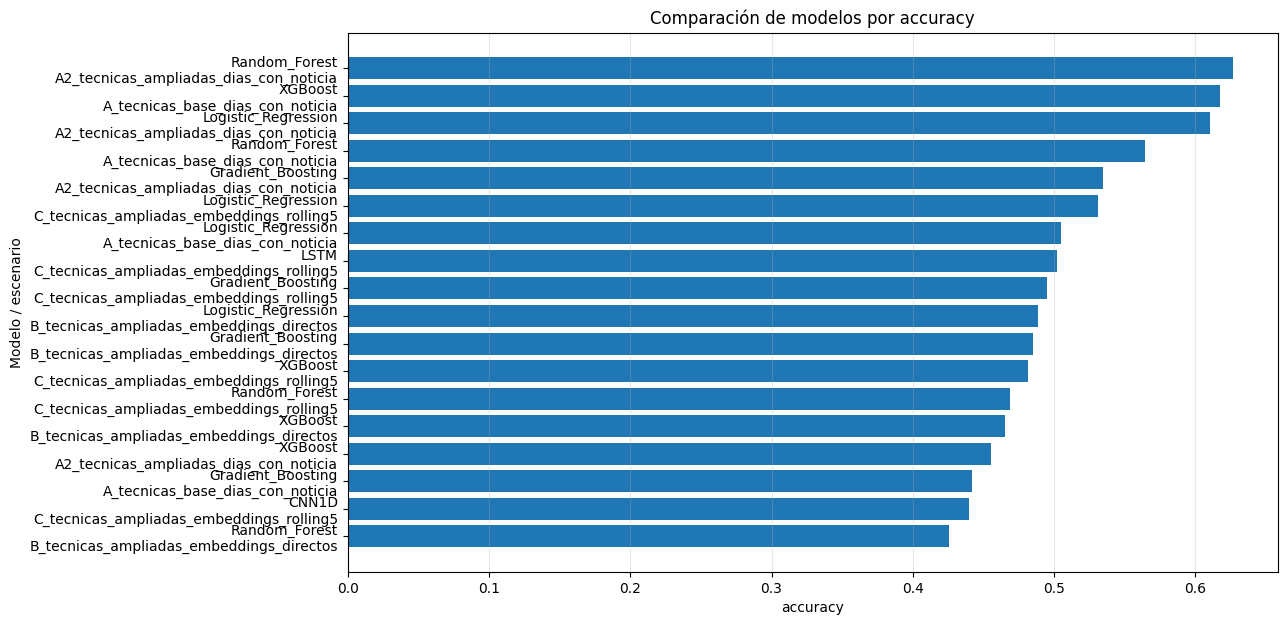

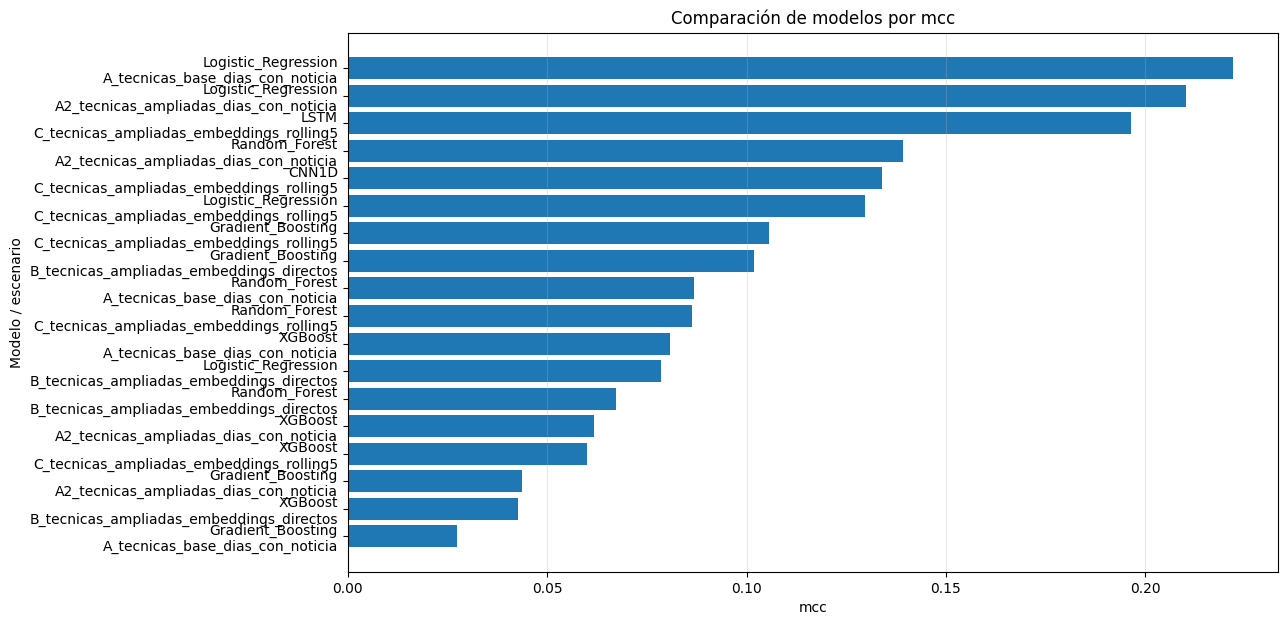

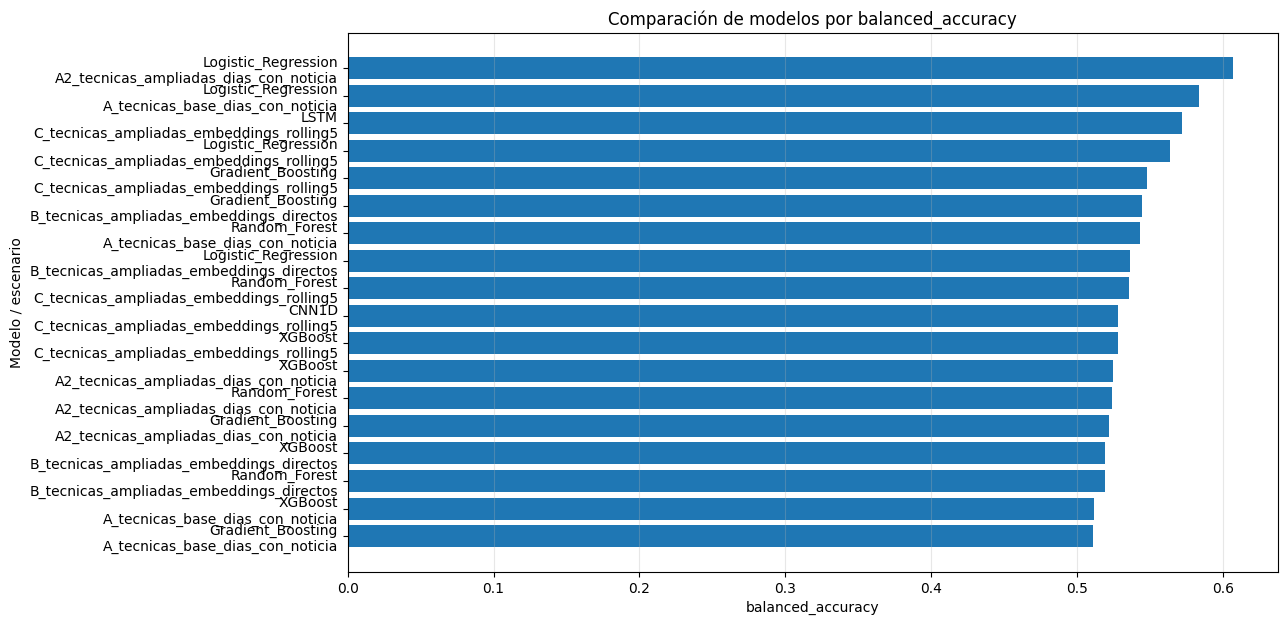

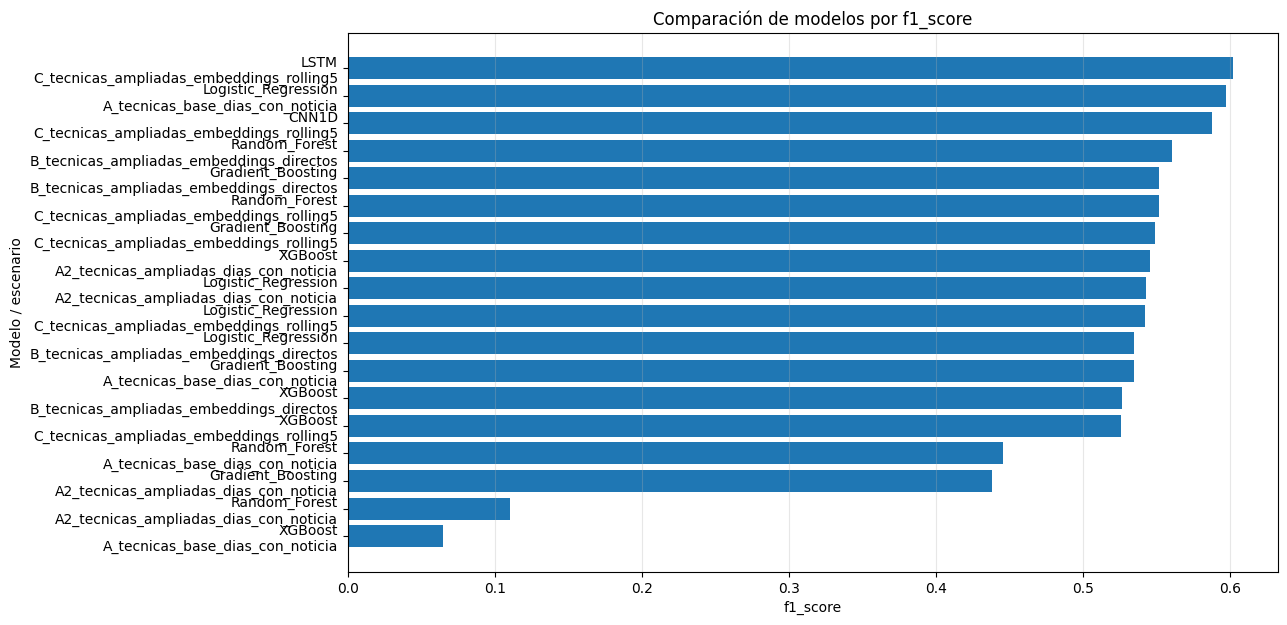

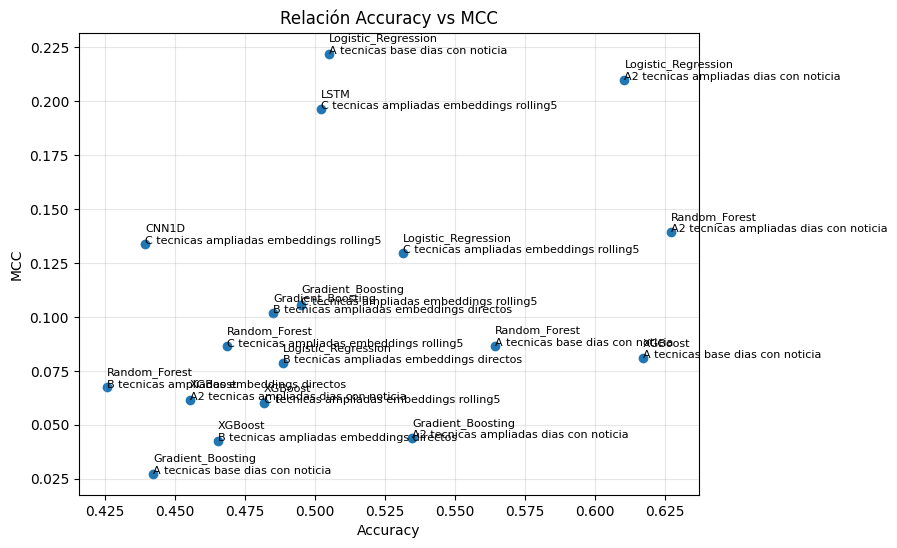

In [ ]:
def plot_metric_comparison(results_df, metric):
    plot_df = results_df.copy()
    plot_df["modelo_final"] = plot_df["modelo"] + "\n" + plot_df["escenario"]

    plot_df = plot_df.sort_values(metric, ascending=True)

    plt.figure(figsize=(12, 7))
    plt.barh(plot_df["modelo_final"], plot_df[metric])
    plt.title(f"Comparación de modelos por {metric}")
    plt.xlabel(metric)
    plt.ylabel("Modelo / escenario")
    plt.grid(axis="x", alpha=0.3)
    plt.show()


plot_metric_comparison(all_results_df, "accuracy")
plot_metric_comparison(all_results_df, "mcc")
plot_metric_comparison(all_results_df, "balanced_accuracy")
plot_metric_comparison(all_results_df, "f1_score")

# Accuracy vs MCC
plt.figure(figsize=(8, 6))
plt.scatter(all_results_df["accuracy"], all_results_df["mcc"])

for _, row in all_results_df.iterrows():
    label = row["modelo"] + "\n" + row["escenario"].replace("_", " ")
    plt.annotate(label, (row["accuracy"], row["mcc"]), fontsize=8)

plt.title("Relación Accuracy vs MCC")
plt.xlabel("Accuracy")
plt.ylabel("MCC")
plt.grid(alpha=0.3)
plt.show()

# Prueba

## 21 - Rollin´ horizon 2025

In [ ]:
# =========================================================
# BLOQUE 21. EVALUACIÓN ESTÁTICA EN 2025
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix
)

# ---------------------------------------------------------
# 1. Validaciones base
# ---------------------------------------------------------

required_objects = [
    "dataset",
    "SCENARIOS",
    "get_classic_models",
    "compute_metrics",
    "find_best_threshold"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(f"No existe '{obj}'. Ejecuta primero los bloques anteriores.")

dataset = dataset.copy()
dataset["fecha"] = pd.to_datetime(dataset["fecha"])
dataset["target"] = dataset["target"].astype(int)

# Asegurar fechas como Timestamp
TEST_START = pd.to_datetime("2025-01-01")
TEST_END = pd.to_datetime("2025-12-31")

# ---------------------------------------------------------
# 2. Definir conjuntos temporales
# ---------------------------------------------------------

# Para evitar seleccionar threshold usando 2025:
# - Entrenamiento interno: antes de 2024
# - Validación interna: 2024
# - Test final: 2025
static_train_internal_df = dataset[dataset["fecha"] < "2024-01-01"].copy()

static_val_internal_df = dataset[
    (dataset["fecha"] >= "2024-01-01") &
    (dataset["fecha"] <= "2024-12-31")
].copy()

train_full_df = dataset[dataset["fecha"] < TEST_START].copy()

test_2025_df = dataset[
    (dataset["fecha"] >= TEST_START) &
    (dataset["fecha"] <= TEST_END)
].copy()

if test_2025_df.empty:
    raise ValueError("No hay datos disponibles para 2025 en dataset.")

print("Train interno threshold:", static_train_internal_df.shape)
print("Validación interna threshold:", static_val_internal_df.shape)
print("Train full 2021-2024:", train_full_df.shape)
print("Test 2025:", test_2025_df.shape)

# ---------------------------------------------------------
# 3. Evaluación estática
# ---------------------------------------------------------

static_2025_results = []
static_2025_predictions = []

for scenario_name, features in SCENARIOS.items():

    print("\n======================================")
    print(f"Escenario estático: {scenario_name}")
    print("Cantidad de features:", len(features))
    print("======================================")

    missing_features = [c for c in features if c not in dataset.columns]
    if missing_features:
        raise ValueError(
            f"Faltan features del escenario {scenario_name}: {missing_features[:50]}"
        )

    X_train_internal = static_train_internal_df[features]
    y_train_internal = static_train_internal_df["target"]

    X_val_internal = static_val_internal_df[features]
    y_val_internal = static_val_internal_df["target"]

    X_train_full = train_full_df[features]
    y_train_full = train_full_df["target"]

    X_test = test_2025_df[features]
    y_test = test_2025_df["target"]

    for model_name, model in get_classic_models().items():

        print(f"Entrenando modelo estático: {model_name}")

        pipe_threshold = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", model)
        ])

        # Entrenamiento interno para buscar threshold
        pipe_threshold.fit(X_train_internal, y_train_internal)
        y_prob_val = pipe_threshold.predict_proba(X_val_internal)[:, 1]

        best_threshold, best_threshold_score = find_best_threshold(
            y_true=y_val_internal,
            y_prob=y_prob_val,
            metric="mcc"
        )

        # Reentrenamiento final con todo 2021-2024
        final_model = get_classic_models()[model_name]

        pipe = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", final_model)
        ])

        pipe.fit(X_train_full, y_train_full)

        y_prob = pipe.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= best_threshold).astype(int)

        metrics = compute_metrics(y_test, y_pred, y_prob)

        metrics.update({
            "modelo": model_name,
            "escenario": scenario_name,
            "tipo_evaluacion": "static_2025",
            "threshold": best_threshold,
            "threshold_mcc_val_2024": best_threshold_score,
            "n_features": len(features),
            "n_obs": len(y_test)
        })

        static_2025_results.append(metrics)

        tmp_pred = test_2025_df[["fecha", "stock", "target", "close"]].copy()
        tmp_pred["modelo"] = model_name
        tmp_pred["escenario"] = scenario_name
        tmp_pred["y_prob"] = y_prob
        tmp_pred["y_pred"] = y_pred
        tmp_pred["threshold"] = best_threshold

        static_2025_predictions.append(tmp_pred)

# ---------------------------------------------------------
# 4. Consolidar resultados
# ---------------------------------------------------------

static_2025_results_df = pd.DataFrame(static_2025_results)
static_2025_results_df = static_2025_results_df.sort_values(
    ["mcc", "accuracy"],
    ascending=False
).reset_index(drop=True)

static_2025_predictions_df = pd.concat(static_2025_predictions, ignore_index=True)

print("======================================")
print("RESULTADOS ESTÁTICOS 2025")
print("======================================")

display(static_2025_results_df)

print("Predicciones estáticas generadas:")
display(static_2025_predictions_df.head())

Train interno threshold: (999, 1610)
Validación interna threshold: (303, 1610)
Train full 2021-2024: (1302, 1610)
Test 2025: (323, 1610)

Escenario estático: A_tecnicas_base_dias_con_noticia
Cantidad de features: 9
Entrenando modelo estático: Logistic_Regression
Entrenando modelo estático: Random_Forest
Entrenando modelo estático: Gradient_Boosting
Entrenando modelo estático: XGBoost

Escenario estático: A2_tecnicas_ampliadas_dias_con_noticia
Cantidad de features: 35
Entrenando modelo estático: Logistic_Regression
Entrenando modelo estático: Random_Forest
Entrenando modelo estático: Gradient_Boosting
Entrenando modelo estático: XGBoost

Escenario estático: B_tecnicas_ampliadas_embeddings_directos
Cantidad de features: 816
Entrenando modelo estático: Logistic_Regression
Entrenando modelo estático: Random_Forest
Entrenando modelo estático: Gradient_Boosting
Entrenando modelo estático: XGBoost

Escenario estático: C_tecnicas_ampliadas_embeddings_rolling5
Cantidad de features: 816
Entrenan

,accuracy,balanced_accuracy,f1_score,mcc,roc_auc,modelo,escenario,tipo_evaluacion,threshold,threshold_mcc_val_2024,n_features,n_obs
0,0.566563,0.588842,0.625668,0.194562,0.585897,XGBoost,C_tecnicas_ampliadas_embeddings_rolling5,static_2025,0.30,0.059980,816,323
1,0.538700,0.571871,0.635697,0.185034,0.564239,Random_Forest,C_tecnicas_ampliadas_embeddings_rolling5,static_2025,0.36,0.086321,816,323
2,0.563467,0.584754,0.619946,0.183926,0.587679,Gradient_Boosting,C_tecnicas_ampliadas_embeddings_rolling5,static_2025,0.30,0.105632,816,323
3,0.557276,0.565072,0.565350,0.130737,0.575010,Logistic_Regression,C_tecnicas_ampliadas_embeddings_rolling5,static_2025,0.30,0.129628,816,323
4,0.554180,0.560345,0.555556,0.120769,0.567299,Logistic_Regression,B_tecnicas_ampliadas_embeddings_directos,static_2025,0.30,0.078581,816,323
5,0.566563,0.559434,0.503546,0.119631,0.560713,XGBoost,A2_tecnicas_ampliadas_dias_con_noticia,static_2025,0.32,0.061717,35,323
6,0.544892,0.556393,0.568915,0.114847,0.583456,Logistic_Regression,A_tecnicas_base_dias_con_noticia,static_2025,0.38,0.222105,9,323
7,0.557276,0.538861,0.421053,0.083165,0.567609,Logistic_Regression,A2_tecnicas_ampliadas_dias_con_noticia,static_2025,0.44,0.210130,35,323
8,0.529412,0.538512,0.544910,0.077757,0.573886,Gradient_Boosting,A_tecnicas_base_dias_con_noticia,static_2025,0.30,0.027310,9,323
9,0.554180,0.503448,0.013699,0.061744,0.556761,XGBoost,A_tecnicas_base_dias_con_noticia,static_2025,0.68,0.080807,9,323


Predicciones estáticas generadas:


,fecha,stock,target,close,modelo,escenario,y_prob,y_pred,threshold
0,2025-01-08,ARG,0,19235.705078,Logistic_Regression,A_tecnicas_base_dias_con_noticia,0.440201,1,0.38
1,2025-01-23,ARG,1,17938.056641,Logistic_Regression,A_tecnicas_base_dias_con_noticia,0.449057,1,0.38
2,2025-01-30,ARG,0,19044.875000,Logistic_Regression,A_tecnicas_base_dias_con_noticia,0.455660,1,0.38
3,2025-02-12,ARG,0,19044.875000,Logistic_Regression,A_tecnicas_base_dias_con_noticia,0.454091,1,0.38
4,2025-02-26,ARG,0,19979.943359,Logistic_Regression,A_tecnicas_base_dias_con_noticia,0.469622,1,0.38


## 22 - Reentrenamiento

In [ ]:
# =========================================================
# BLOQUE 22. ROLLING HORIZON 2025 CON REENTRENAMIENTO
# =========================================================

# ---------------------------------------------------------
# 1. Validaciones base
# ---------------------------------------------------------

required_objects = [
    "dataset",
    "all_results_df",
    "SCENARIOS",
    "get_classic_models",
    "find_best_threshold"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(f"No existe '{obj}'. Ejecuta primero los bloques anteriores.")

dataset = dataset.copy()
dataset["fecha"] = pd.to_datetime(dataset["fecha"])
dataset["target"] = dataset["target"].astype(int)
dataset["stock"] = dataset["stock"].astype(str)

TEST_START = pd.to_datetime("2025-01-01")
TEST_END = pd.to_datetime("2025-12-31")

ROLLING_RETRAIN_EVERY_N_DAYS = 1
MIN_TRAIN_ROWS_ROLLING = 300

# ---------------------------------------------------------
# 2. Seleccionar mejor modelo clásico desde validación 2024
# ---------------------------------------------------------

classic_only_sorted = all_results_df[
    all_results_df["tipo_modelo"].astype(str).str.contains("Clasico", case=False, na=False)
].copy()

if classic_only_sorted.empty:
    raise ValueError(
        "No se encontraron modelos clásicos en all_results_df. "
        "Revisa la columna tipo_modelo."
    )

classic_only_sorted = classic_only_sorted.sort_values(
    ["mcc", "accuracy"],
    ascending=False
).reset_index(drop=True)

print("======================================")
print("RANKING DE MODELOS CLÁSICOS PARA ROLLING")
print("======================================")
display(classic_only_sorted)

BEST_CLASSIC_ROW = classic_only_sorted.iloc[0]

ROLLING_MODEL_NAME = BEST_CLASSIC_ROW["modelo"]
ROLLING_SCENARIO = BEST_CLASSIC_ROW["escenario"]

if ROLLING_SCENARIO not in SCENARIOS:
    raise ValueError(
        f"El escenario {ROLLING_SCENARIO} no existe en SCENARIOS."
    )

ROLLING_FEATURES = SCENARIOS[ROLLING_SCENARIO]

missing_features = [c for c in ROLLING_FEATURES if c not in dataset.columns]

if missing_features:
    raise ValueError(
        f"Faltan features para rolling: {missing_features[:50]}"
    )

print("======================================")
print("MODELO SELECCIONADO PARA ROLLING")
print("======================================")
print("Modelo:", ROLLING_MODEL_NAME)
print("Escenario:", ROLLING_SCENARIO)
print("Features:", len(ROLLING_FEATURES))
print("MCC validación 2024:", BEST_CLASSIC_ROW["mcc"])
print("Accuracy validación 2024:", BEST_CLASSIC_ROW["accuracy"])

# ---------------------------------------------------------
# 3. Función de entrenamiento por fecha
# ---------------------------------------------------------

def train_classic_for_period(
    model_name,
    train_data,
    features,
    threshold_metric="mcc"
):
    """
    Entrena un modelo clásico usando únicamente datos anteriores
    a la fecha de predicción.
    """

    train_data = train_data.sort_values(["fecha", "stock"]).copy()

    if len(train_data) < 50:
        raise ValueError(f"Muy pocas filas para entrenar: {len(train_data)}")

    if train_data["target"].nunique() < 2:
        raise ValueError("El target tiene una sola clase en train_data.")

    split_idx = int(len(train_data) * 0.80)

    inner_train = train_data.iloc[:split_idx].copy()
    inner_val = train_data.iloc[split_idx:].copy()

    if len(inner_val) < 30 or inner_val["target"].nunique() < 2:
        inner_train = train_data.copy()
        inner_val = train_data.copy()

    X_train = inner_train[features]
    y_train = inner_train["target"]

    X_val = inner_val[features]
    y_val = inner_val["target"]

    model = get_classic_models()[model_name]

    pipe_threshold = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe_threshold.fit(X_train, y_train)

    y_prob_val = pipe_threshold.predict_proba(X_val)[:, 1]

    best_threshold, best_threshold_score = find_best_threshold(
        y_true=y_val,
        y_prob=y_prob_val,
        metric=threshold_metric
    )

    final_model = get_classic_models()[model_name]

    pipe_final = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", final_model)
    ])

    pipe_final.fit(train_data[features], train_data["target"])

    return pipe_final, best_threshold, best_threshold_score

# ---------------------------------------------------------
# 4. Función rolling horizon
# ---------------------------------------------------------

def rolling_horizon_2025(
    dataset,
    model_name,
    scenario_name,
    features,
    test_start,
    test_end,
    retrain_every_n_days=1,
    min_train_rows=300
):
    """
    Rolling horizon real.
    Para cada fecha de 2025:
    - Entrena con todo lo anterior.
    - Predice esa fecha.
    - Avanza al siguiente día disponible.
    """

    data = dataset.copy()
    data["fecha"] = pd.to_datetime(data["fecha"])
    data = data.sort_values(["fecha", "stock"]).reset_index(drop=True)

    prediction_dates = sorted(
        data[
            (data["fecha"] >= test_start) &
            (data["fecha"] <= test_end)
        ]["fecha"].unique()
    )

    if len(prediction_dates) == 0:
        raise ValueError("No hay fechas disponibles para predecir en 2025.")

    all_predictions = []

    current_model = None
    current_threshold = None
    current_threshold_score = None
    last_retrain_date = None

    retrain_count = 0
    skipped_dates = 0

    for i, current_date in enumerate(tqdm(prediction_dates, desc="Rolling horizon 2025")):

        current_date = pd.to_datetime(current_date)

        train_roll = data[data["fecha"] < current_date].copy()
        pred_roll = data[data["fecha"] == current_date].copy()

        if len(train_roll) < min_train_rows:
            skipped_dates += 1
            continue

        if pred_roll.empty:
            skipped_dates += 1
            continue

        if train_roll["target"].nunique() < 2:
            skipped_dates += 1
            continue

        should_retrain = (
            current_model is None or
            i % retrain_every_n_days == 0
        )

        if should_retrain:
            current_model, current_threshold, current_threshold_score = train_classic_for_period(
                model_name=model_name,
                train_data=train_roll,
                features=features,
                threshold_metric="mcc"
            )

            retrain_count += 1
            last_retrain_date = current_date

        X_pred = pred_roll[features]

        y_prob = current_model.predict_proba(X_pred)[:, 1]
        y_pred = (y_prob >= current_threshold).astype(int)

        tmp = pred_roll[["fecha", "stock", "target", "close"]].copy()

        tmp["y_prob"] = y_prob
        tmp["y_pred"] = y_pred
        tmp["threshold"] = current_threshold
        tmp["threshold_score_internal"] = current_threshold_score
        tmp["model"] = model_name
        tmp["scenario"] = scenario_name
        tmp["last_retrain_date"] = last_retrain_date
        tmp["train_rows_available"] = len(train_roll)

        all_predictions.append(tmp)

    if len(all_predictions) == 0:
        raise ValueError(
            "El rolling horizon no generó predicciones. "
            "Revisa fechas, min_train_rows o distribución del target."
        )

    rolling_pred_df = pd.concat(all_predictions, ignore_index=True)

    print("======================================")
    print("RESUMEN ROLLING HORIZON 2025")
    print("======================================")
    print("Fechas disponibles 2025:", len(prediction_dates))
    print("Fechas omitidas:", skipped_dates)
    print("Reentrenamientos realizados:", retrain_count)
    print("Predicciones generadas:", len(rolling_pred_df))
    print("Stocks predichos:", sorted(rolling_pred_df["stock"].unique()))
    print("Rango predicho:", rolling_pred_df["fecha"].min(), "->", rolling_pred_df["fecha"].max())

    return rolling_pred_df

# ---------------------------------------------------------
# 5. Ejecutar rolling
# ---------------------------------------------------------

rolling_pred_df = rolling_horizon_2025(
    dataset=dataset,
    model_name=ROLLING_MODEL_NAME,
    scenario_name=ROLLING_SCENARIO,
    features=ROLLING_FEATURES,
    test_start=TEST_START,
    test_end=TEST_END,
    retrain_every_n_days=ROLLING_RETRAIN_EVERY_N_DAYS,
    min_train_rows=MIN_TRAIN_ROWS_ROLLING
)

print("======================================")
print("rolling_pred_df creado correctamente")
print("======================================")
print("Shape:", rolling_pred_df.shape)

display(rolling_pred_df.head())
display(rolling_pred_df.tail())

RANKING DE MODELOS CLÁSICOS PARA ROLLING


,accuracy,balanced_accuracy,f1_score,mcc,roc_auc,modelo,escenario,threshold,n_features,tipo_modelo,lookback,n_train_seq,n_val_seq
0,0.504950,0.583852,0.596774,0.222105,0.573317,Logistic_Regression,A_tecnicas_base_dias_con_noticia,0.38,9,Clasico,NaN,NaN,NaN
1,0.610561,0.607421,0.542636,0.210130,0.620110,Logistic_Regression,A2_tecnicas_ampliadas_dias_con_noticia,0.44,35,Clasico,NaN,NaN,NaN
2,0.627063,0.524256,0.110236,0.139339,0.540357,Random_Forest,A2_tecnicas_ampliadas_dias_con_noticia,0.59,35,Clasico,NaN,NaN,NaN
3,0.531353,0.564040,0.541935,0.129628,0.521301,Logistic_Regression,C_tecnicas_ampliadas_embeddings_rolling5,0.30,816,Clasico,NaN,NaN,NaN
4,0.495050,0.548122,0.548673,0.105632,0.523317,Gradient_Boosting,C_tecnicas_ampliadas_embeddings_rolling5,0.30,816,Clasico,NaN,NaN,NaN
5,0.485149,0.544617,0.551724,0.101751,0.507696,Gradient_Boosting,B_tecnicas_ampliadas_embeddings_directos,0.32,816,Clasico,NaN,NaN,NaN
6,0.564356,0.543495,0.445378,0.086733,0.532272,Random_Forest,A_tecnicas_base_dias_con_noticia,0.48,9,Clasico,NaN,NaN,NaN
7,0.468647,0.535708,0.551532,0.086321,0.477325,Random_Forest,C_tecnicas_ampliadas_embeddings_rolling5,0.36,816,Clasico,NaN,NaN,NaN
8,0.617162,0.511544,0.064516,0.080807,0.511796,XGBoost,A_tecnicas_base_dias_con_noticia,0.68,9,Clasico,NaN,NaN,NaN
9,0.488449,0.536578,0.534535,0.078581,0.523820,Logistic_Regression,B_tecnicas_ampliadas_embeddings_directos,0.30,816,Clasico,NaN,NaN,NaN


MODELO SELECCIONADO PARA ROLLING
Modelo: Logistic_Regression
Escenario: A_tecnicas_base_dias_con_noticia
Features: 9
MCC validación 2024: 0.2221048093755793
Accuracy validación 2024: 0.504950495049505


Rolling horizon 2025:   0%|          | 0/203 [00:00<?, ?it/s]

RESUMEN ROLLING HORIZON 2025
Fechas disponibles 2025: 203
Fechas omitidas: 0
Reentrenamientos realizados: 203
Predicciones generadas: 323
Stocks predichos: ['ARG', 'CIBEST', 'EC', 'NCH']
Rango predicho: 2025-01-02 00:00:00 -> 2025-12-31 00:00:00
rolling_pred_df creado correctamente
Shape: (323, 12)


,fecha,stock,target,close,y_prob,y_pred,threshold,threshold_score_internal,model,scenario,last_retrain_date,train_rows_available
0,2025-01-02,NCH,1,79000.000000,0.222844,0,0.40,0.213841,Logistic_Regression,A_tecnicas_base_dias_con_noticia,2025-01-02,1302
1,2025-01-03,EC,1,7.453026,0.528200,1,0.38,0.210668,Logistic_Regression,A_tecnicas_base_dias_con_noticia,2025-01-03,1303
2,2025-01-03,NCH,1,81980.000000,0.252505,0,0.38,0.210668,Logistic_Regression,A_tecnicas_base_dias_con_noticia,2025-01-03,1303
3,2025-01-08,ARG,0,19235.705078,0.444225,1,0.38,0.192698,Logistic_Regression,A_tecnicas_base_dias_con_noticia,2025-01-08,1305
4,2025-01-13,CIBEST,0,33612.074219,0.427171,1,0.38,0.191005,Logistic_Regression,A_tecnicas_base_dias_con_noticia,2025-01-13,1306


,fecha,stock,target,close,y_prob,y_pred,threshold,threshold_score_internal,model,scenario,last_retrain_date,train_rows_available
318,2025-12-22,EC,1,9.300000,0.513934,1,0.3,0.137164,Logistic_Regression,A_tecnicas_base_dias_con_noticia,2025-12-22,1619
319,2025-12-23,ARG,1,16536.035156,0.515258,1,0.3,0.133993,Logistic_Regression,A_tecnicas_base_dias_con_noticia,2025-12-23,1621
320,2025-12-29,EC,1,9.840000,0.492684,1,0.3,0.137558,Logistic_Regression,A_tecnicas_base_dias_con_noticia,2025-12-29,1622
321,2025-12-29,NCH,0,282000.000000,0.187342,0,0.3,0.137558,Logistic_Regression,A_tecnicas_base_dias_con_noticia,2025-12-29,1622
322,2025-12-31,NCH,0,282000.000000,0.178034,0,0.3,0.143354,Logistic_Regression,A_tecnicas_base_dias_con_noticia,2025-12-31,1624


## 23 - Evaluación prueba

MÉTRICAS GLOBALES - ROLLING HORIZON 2025


,modelo,escenario,tipo_evaluacion,n_obs,fecha_min,fecha_max,target_1_rate,pred_1_rate,accuracy,balanced_accuracy,f1_score,mcc,roc_auc
0,Logistic_Regression,A_tecnicas_base_dias_con_noticia,rolling_horizon_2025,323,2025-01-02,2025-12-31,0.448916,0.563467,0.557276,0.564432,0.562691,0.129236,0.578419


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Baja       0.62      0.49      0.55       178
        Sube       0.51      0.63      0.56       145

    accuracy                           0.56       323
   macro avg       0.56      0.56      0.56       323
weighted avg       0.57      0.56      0.56       323



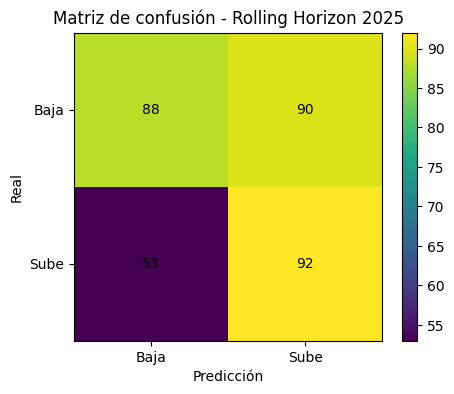

MÉTRICAS POR STOCK - ROLLING HORIZON 2025


,accuracy,balanced_accuracy,f1_score,mcc,roc_auc,stock,n_obs,fecha_min,fecha_max,target_1_rate,pred_1_rate
0,0.701299,0.550385,0.206897,0.212622,0.463077,NCH,77,2025-01-02,2025-12-31,0.324675,0.051948
1,0.542169,0.538908,0.641509,0.092602,0.523229,CIBEST,83,2025-01-13,2025-12-22,0.506024,0.771084
2,0.512605,0.514689,0.608108,0.033828,0.559605,EC,119,2025-01-03,2025-12-29,0.495798,0.747899
3,0.454545,0.463158,0.454545,-0.073684,0.532632,ARG,44,2025-01-08,2025-12-23,0.431818,0.568182


MÉTRICAS POR MES - ROLLING HORIZON 2025


,accuracy,balanced_accuracy,f1_score,mcc,roc_auc,year_month,n_obs,target_1_rate,pred_1_rate
0,0.565217,0.556818,0.642857,0.123366,0.621212,2025-01,23,0.521739,0.695652
1,0.461538,0.488095,0.588235,-0.032898,0.446429,2025-02,26,0.461538,0.846154
2,0.500000,0.500000,0.600000,0.000000,0.465278,2025-03,24,0.500000,0.750000
3,0.640000,0.597222,0.470588,0.200082,0.444444,2025-04,25,0.360000,0.320000
4,0.607143,0.541667,0.153846,0.222222,0.796875,2025-05,28,0.428571,0.035714
5,0.555556,0.516667,0.250000,0.046625,0.666667,2025-06,27,0.444444,0.148148
6,0.600000,0.540000,0.363636,0.076139,0.568000,2025-07,35,0.285714,0.342857
7,0.608696,0.579365,0.689655,0.162650,0.738095,2025-08,23,0.608696,0.652174
8,0.571429,0.614583,0.647059,0.276385,0.666667,2025-09,28,0.428571,0.785714
9,0.500000,0.500000,0.634146,0.000000,0.484444,2025-10,30,0.500000,0.866667


In [ ]:
# =========================================================
# BLOQUE 23. EVALUACIÓN DEL ROLLING HORIZON 2025
# =========================================================

# ---------------------------------------------------------
# 1. Validar rolling_pred_df
# ---------------------------------------------------------

if "rolling_pred_df" not in globals():
    raise NameError(
        "No existe rolling_pred_df. Ejecuta primero el Bloque 22."
    )

if rolling_pred_df.empty:
    raise ValueError(
        "rolling_pred_df está vacío. El rolling no generó predicciones."
    )

required_cols = ["fecha", "stock", "target", "y_pred", "y_prob"]

missing_cols = [c for c in required_cols if c not in rolling_pred_df.columns]

if missing_cols:
    raise ValueError(
        f"rolling_pred_df no tiene las columnas necesarias: {missing_cols}"
    )

rolling_pred_df["fecha"] = pd.to_datetime(rolling_pred_df["fecha"])
rolling_pred_df["target"] = rolling_pred_df["target"].astype(int)
rolling_pred_df["y_pred"] = rolling_pred_df["y_pred"].astype(int)
rolling_pred_df["y_prob"] = rolling_pred_df["y_prob"].astype(float)

# ---------------------------------------------------------
# 2. Métricas globales
# ---------------------------------------------------------

rolling_metrics = compute_metrics(
    y_true=rolling_pred_df["target"],
    y_pred=rolling_pred_df["y_pred"],
    y_prob=rolling_pred_df["y_prob"]
)

rolling_metrics_df = pd.DataFrame([{
    "modelo": ROLLING_MODEL_NAME,
    "escenario": ROLLING_SCENARIO,
    "tipo_evaluacion": "rolling_horizon_2025",
    "n_obs": len(rolling_pred_df),
    "fecha_min": rolling_pred_df["fecha"].min(),
    "fecha_max": rolling_pred_df["fecha"].max(),
    "target_1_rate": rolling_pred_df["target"].mean(),
    "pred_1_rate": rolling_pred_df["y_pred"].mean(),
    **rolling_metrics
}])

print("======================================")
print("MÉTRICAS GLOBALES - ROLLING HORIZON 2025")
print("======================================")

display(rolling_metrics_df)

print("======================================")
print("CLASSIFICATION REPORT")
print("======================================")

print(classification_report(
    rolling_pred_df["target"],
    rolling_pred_df["y_pred"],
    labels=[0, 1],
    target_names=["Baja", "Sube"],
    zero_division=0
))

# ---------------------------------------------------------
# 3. Matriz de confusión
# ---------------------------------------------------------

plot_confusion_matrix_simple(
    rolling_pred_df["target"],
    rolling_pred_df["y_pred"],
    title="Matriz de confusión - Rolling Horizon 2025"
)

# ---------------------------------------------------------
# 4. Métricas por stock
# ---------------------------------------------------------

rolling_metrics_by_stock = []

for stock, g in rolling_pred_df.groupby("stock"):

    m = compute_metrics(
        y_true=g["target"],
        y_pred=g["y_pred"],
        y_prob=g["y_prob"]
    )

    m["stock"] = stock
    m["n_obs"] = len(g)
    m["fecha_min"] = g["fecha"].min()
    m["fecha_max"] = g["fecha"].max()
    m["target_1_rate"] = g["target"].mean()
    m["pred_1_rate"] = g["y_pred"].mean()

    rolling_metrics_by_stock.append(m)

rolling_metrics_by_stock_df = pd.DataFrame(rolling_metrics_by_stock)
rolling_metrics_by_stock_df = rolling_metrics_by_stock_df.sort_values(
    ["mcc", "accuracy"],
    ascending=False
).reset_index(drop=True)

print("======================================")
print("MÉTRICAS POR STOCK - ROLLING HORIZON 2025")
print("======================================")

display(rolling_metrics_by_stock_df)

# ---------------------------------------------------------
# 5. Métricas por mes
# ---------------------------------------------------------

rolling_pred_df["year_month"] = rolling_pred_df["fecha"].dt.to_period("M").astype(str)

rolling_metrics_by_month = []

for month, g in rolling_pred_df.groupby("year_month"):

    if len(g) < 5:
        continue

    m = compute_metrics(
        y_true=g["target"],
        y_pred=g["y_pred"],
        y_prob=g["y_prob"]
    )

    m["year_month"] = month
    m["n_obs"] = len(g)
    m["target_1_rate"] = g["target"].mean()
    m["pred_1_rate"] = g["y_pred"].mean()

    rolling_metrics_by_month.append(m)

rolling_metrics_by_month_df = pd.DataFrame(rolling_metrics_by_month)

print("======================================")
print("MÉTRICAS POR MES - ROLLING HORIZON 2025")
print("======================================")

display(rolling_metrics_by_month_df)

## 24 - Gráfica rollin´ horizon

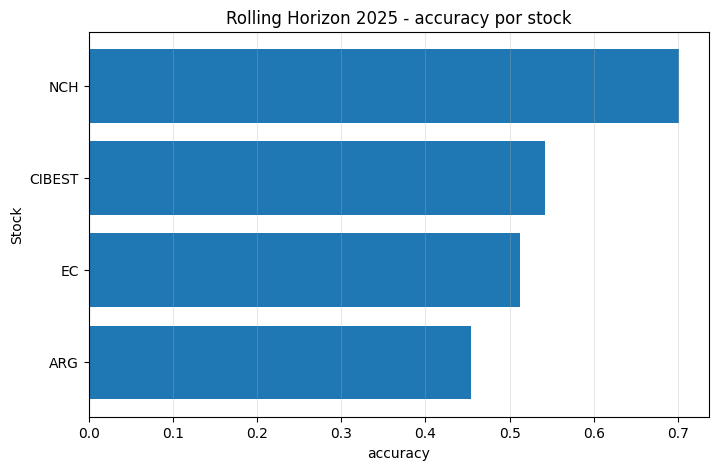

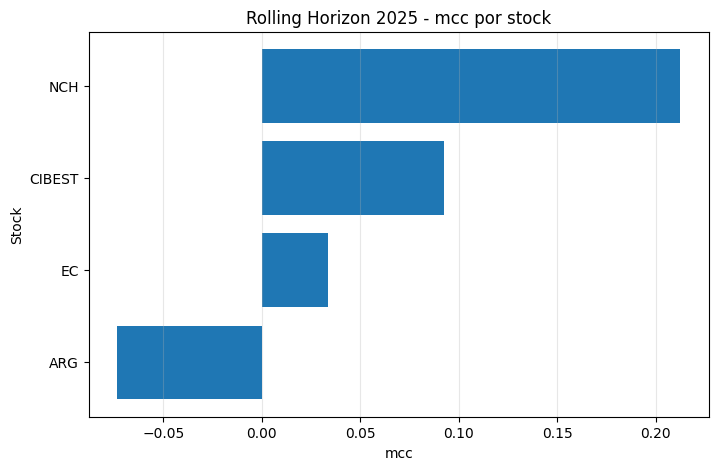

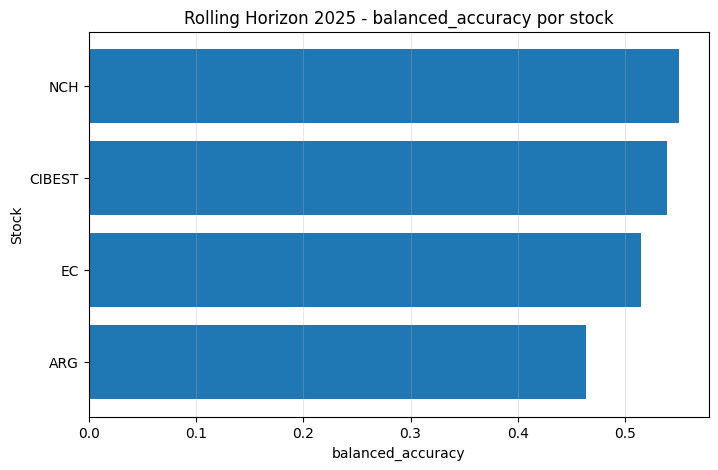

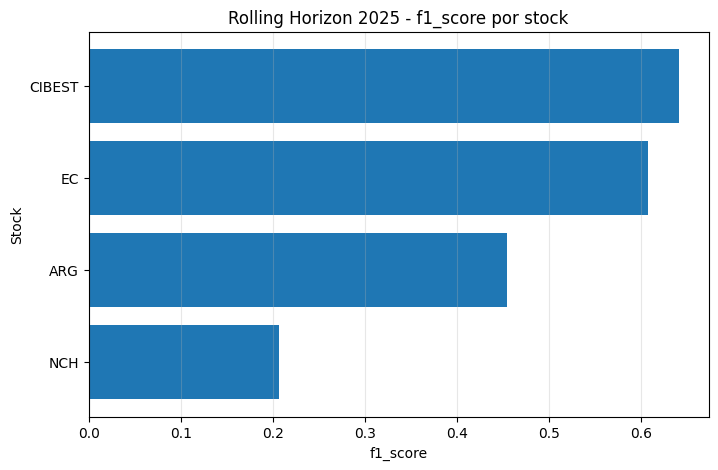

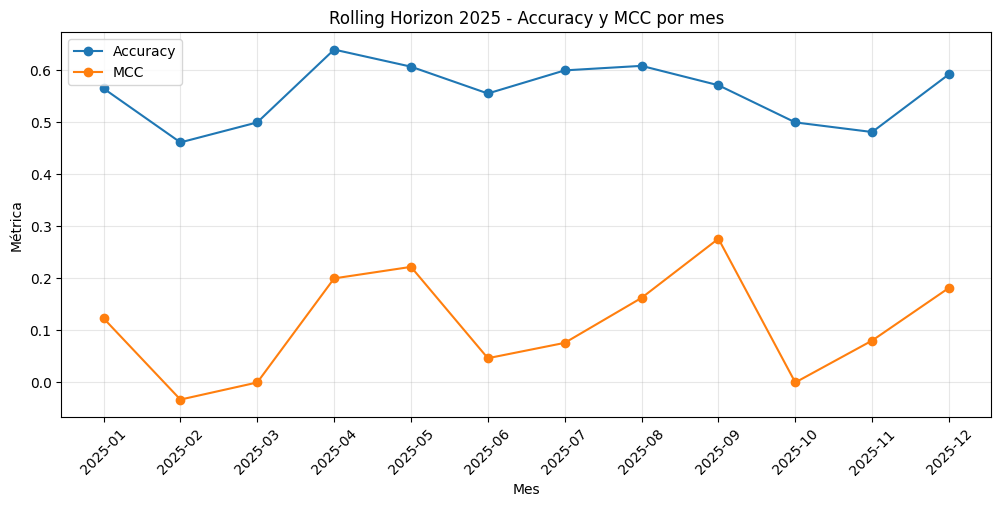

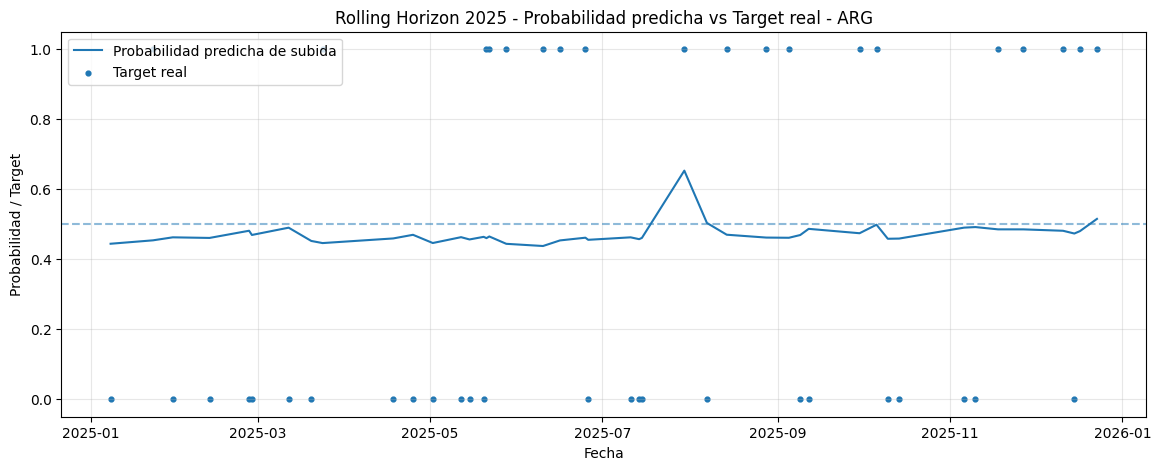

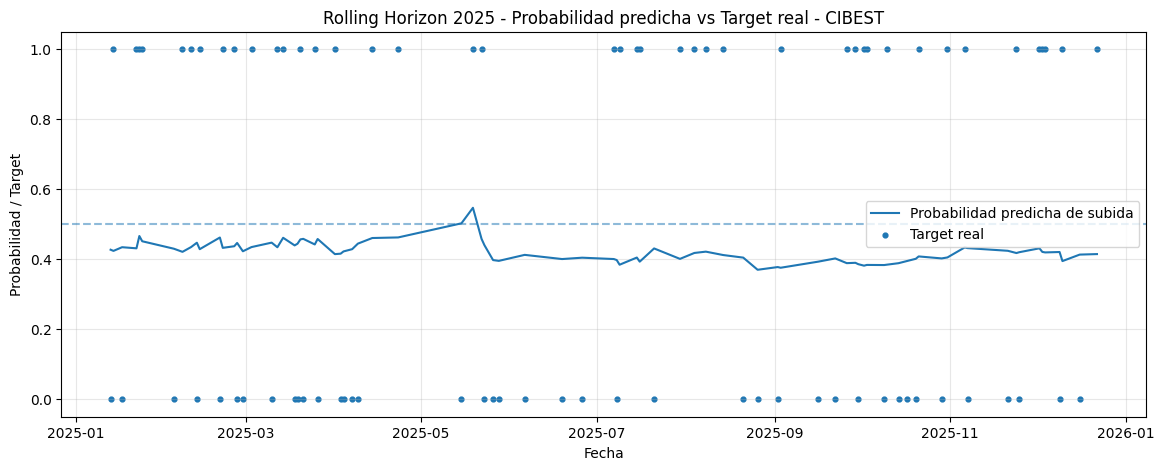

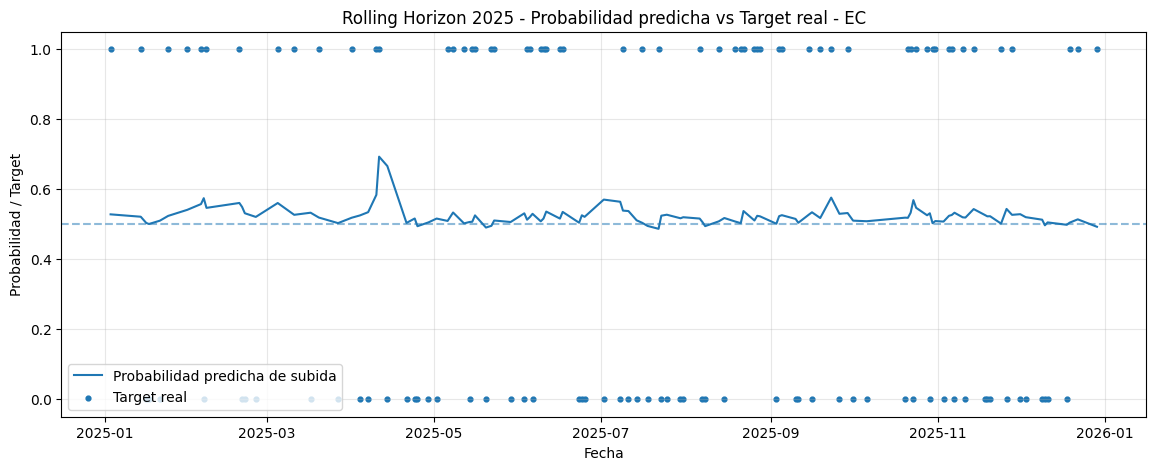

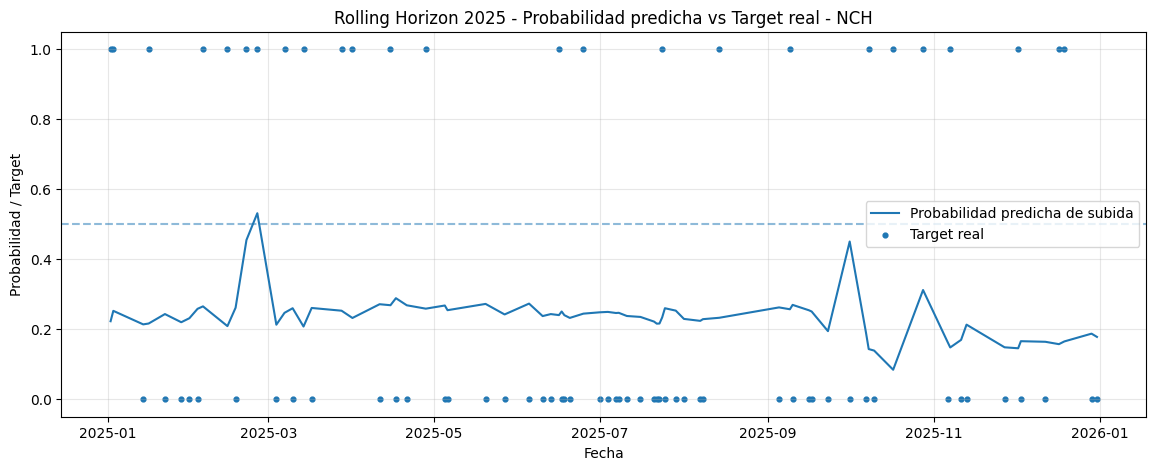

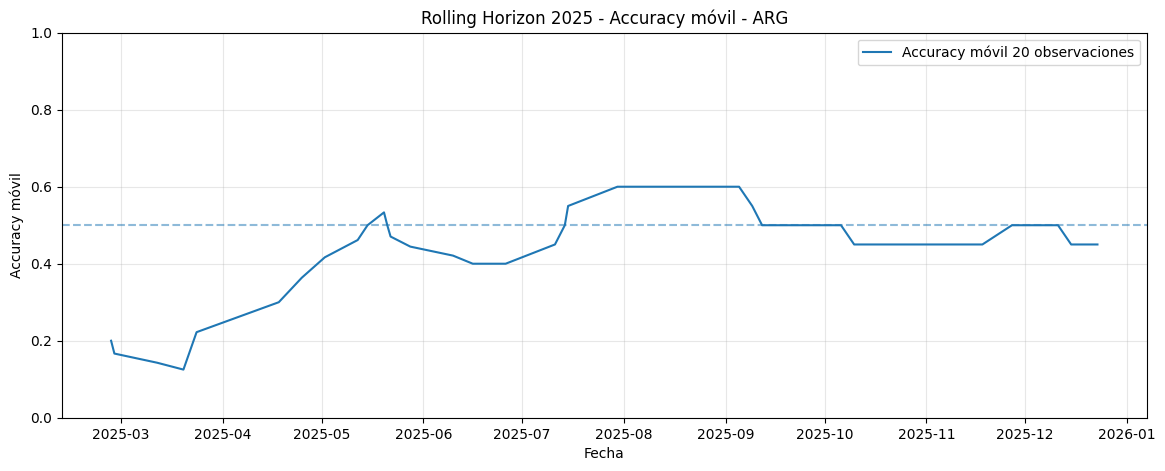

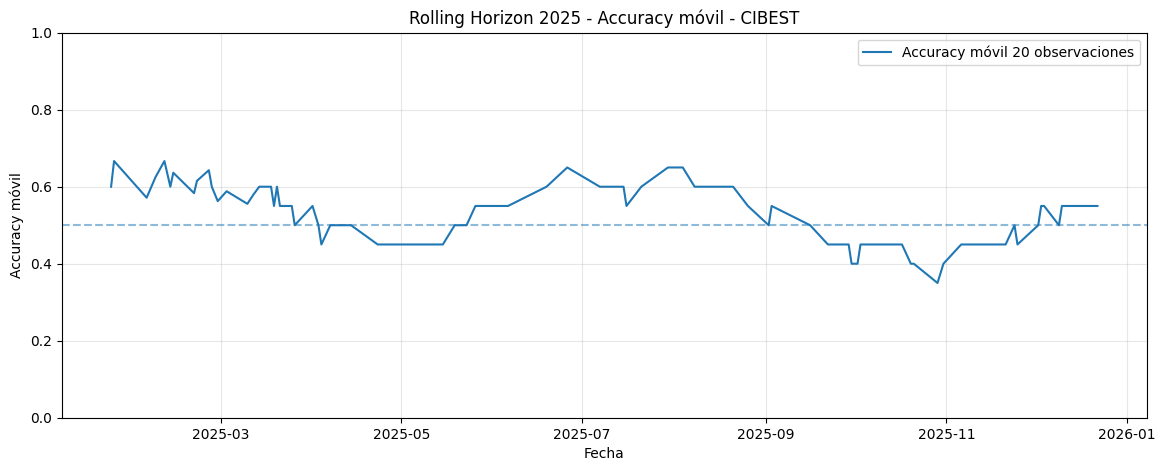

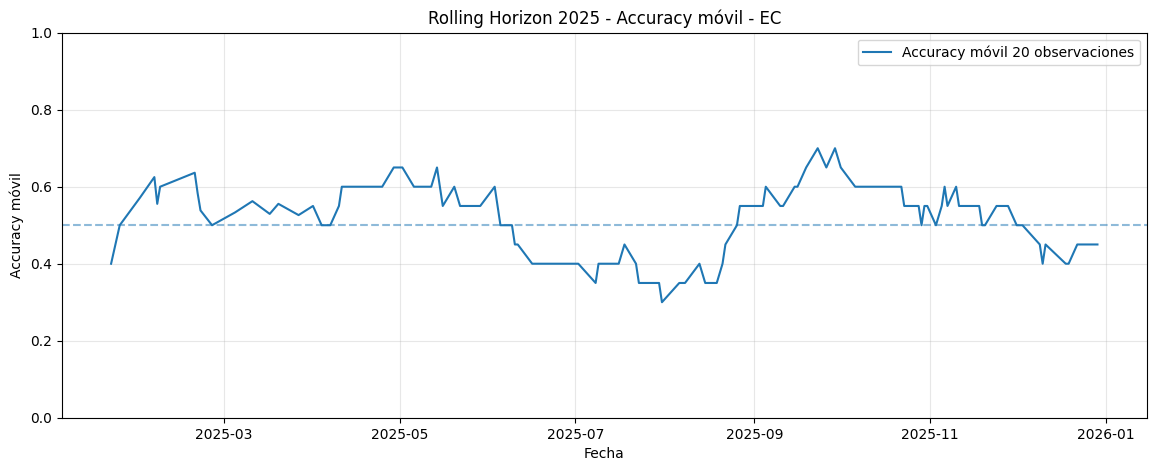

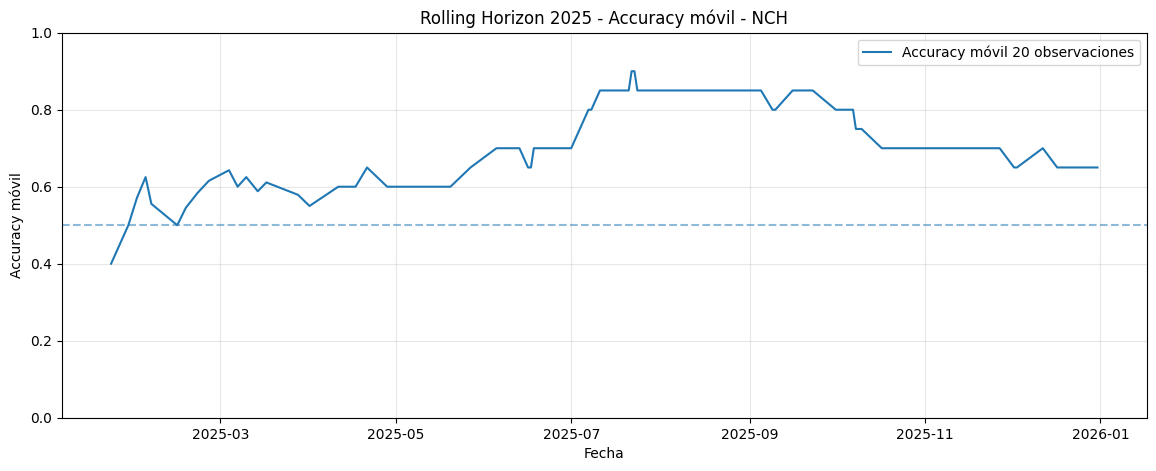

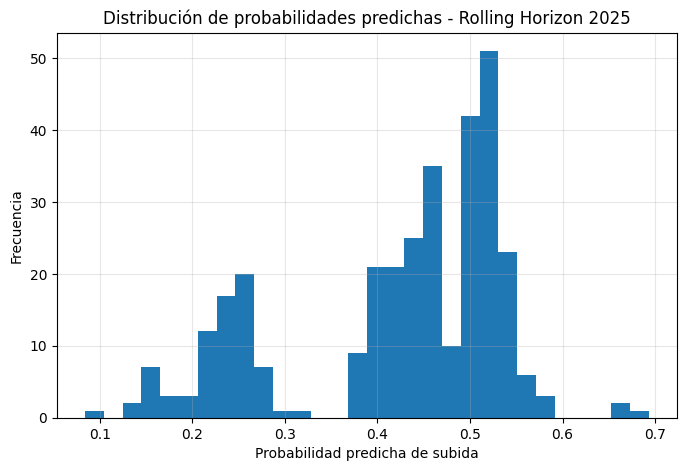

,variable,proporcion
0,target_real_1_rate,0.448916
1,prediccion_1_rate,0.563467


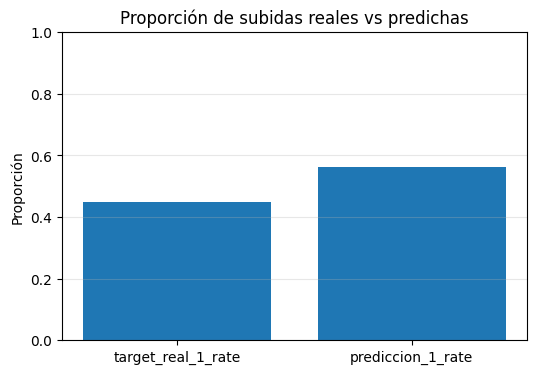

In [ ]:
# =========================================================
# BLOQUE 24. GRÁFICAS DEL ROLLING HORIZON 2025
# =========================================================

# ---------------------------------------------------------
# 1. Validaciones
# ---------------------------------------------------------

required_objects = [
    "rolling_pred_df",
    "rolling_metrics_by_stock_df",
    "rolling_metrics_by_month_df"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(f"No existe '{obj}'. Ejecuta primero el Bloque 23.")

# ---------------------------------------------------------
# 2. Métricas por stock
# ---------------------------------------------------------

for metric in ["accuracy", "mcc", "balanced_accuracy", "f1_score"]:

    if metric not in rolling_metrics_by_stock_df.columns:
        continue

    plot_df = rolling_metrics_by_stock_df.sort_values(metric, ascending=True)

    plt.figure(figsize=(8, 5))
    plt.barh(plot_df["stock"], plot_df[metric])
    plt.title(f"Rolling Horizon 2025 - {metric} por stock")
    plt.xlabel(metric)
    plt.ylabel("Stock")
    plt.grid(axis="x", alpha=0.3)
    plt.show()

# ---------------------------------------------------------
# 3. Accuracy y MCC por mes
# ---------------------------------------------------------

if not rolling_metrics_by_month_df.empty:

    plt.figure(figsize=(12, 5))

    plt.plot(
        rolling_metrics_by_month_df["year_month"],
        rolling_metrics_by_month_df["accuracy"],
        marker="o",
        label="Accuracy"
    )

    plt.plot(
        rolling_metrics_by_month_df["year_month"],
        rolling_metrics_by_month_df["mcc"],
        marker="o",
        label="MCC"
    )

    plt.title("Rolling Horizon 2025 - Accuracy y MCC por mes")
    plt.xlabel("Mes")
    plt.ylabel("Métrica")
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

else:
    print("No hay métricas mensuales suficientes para graficar.")

# ---------------------------------------------------------
# 4. Probabilidad predicha vs target real por stock
# ---------------------------------------------------------

for stock, g in rolling_pred_df.groupby("stock"):

    g = g.sort_values("fecha").copy()

    plt.figure(figsize=(14, 5))

    plt.plot(
        g["fecha"],
        g["y_prob"],
        label="Probabilidad predicha de subida"
    )

    plt.scatter(
        g["fecha"],
        g["target"],
        label="Target real",
        s=12
    )

    plt.axhline(0.5, linestyle="--", alpha=0.5)

    plt.title(f"Rolling Horizon 2025 - Probabilidad predicha vs Target real - {stock}")
    plt.xlabel("Fecha")
    plt.ylabel("Probabilidad / Target")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# ---------------------------------------------------------
# 5. Accuracy móvil por stock
# ---------------------------------------------------------

rolling_pred_df["correct"] = (
    rolling_pred_df["target"] == rolling_pred_df["y_pred"]
).astype(int)

for stock, g in rolling_pred_df.groupby("stock"):

    g = g.sort_values("fecha").copy()

    g["rolling_accuracy_20"] = (
        g["correct"]
        .rolling(window=20, min_periods=5)
        .mean()
    )

    plt.figure(figsize=(14, 5))

    plt.plot(
        g["fecha"],
        g["rolling_accuracy_20"],
        label="Accuracy móvil 20 observaciones"
    )

    plt.axhline(0.5, linestyle="--", alpha=0.5)

    plt.title(f"Rolling Horizon 2025 - Accuracy móvil - {stock}")
    plt.xlabel("Fecha")
    plt.ylabel("Accuracy móvil")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

# ---------------------------------------------------------
# 6. Distribución de probabilidades
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.hist(rolling_pred_df["y_prob"], bins=30)
plt.title("Distribución de probabilidades predichas - Rolling Horizon 2025")
plt.xlabel("Probabilidad predicha de subida")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.3)
plt.show()

# ---------------------------------------------------------
# 7. Proporción real vs predicha
# ---------------------------------------------------------

comparison_summary = pd.DataFrame({
    "variable": ["target_real_1_rate", "prediccion_1_rate"],
    "proporcion": [
        rolling_pred_df["target"].mean(),
        rolling_pred_df["y_pred"].mean()
    ]
})

display(comparison_summary)

plt.figure(figsize=(6, 4))
plt.bar(comparison_summary["variable"], comparison_summary["proporcion"])
plt.title("Proporción de subidas reales vs predichas")
plt.ylabel("Proporción")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.show()

## 25 - Savin´ resultados

In [ ]:
# =========================================================
# BLOQUE 25. EXPORTAR RESULTADOS E INTERPRETACIÓN
# =========================================================

# ---------------------------------------------------------
# 1. Validaciones
# ---------------------------------------------------------

required_objects = [
    "all_results_df",
    "static_2025_results_df",
    "static_2025_predictions_df",
    "rolling_pred_df",
    "rolling_metrics_df",
    "rolling_metrics_by_stock_df",
    "rolling_metrics_by_month_df"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(f"No existe '{obj}'. Ejecuta los bloques anteriores.")

# ---------------------------------------------------------
# 2. Exportar archivos
# ---------------------------------------------------------

OUTPUT_DIR = "/content/drive/MyDrive/EAFIT/TESIS/RZK/resultados_modelos"
os.makedirs(OUTPUT_DIR, exist_ok=True)

all_results_df.to_csv(
    os.path.join(OUTPUT_DIR, "comparacion_modelos_validacion_2024.csv"),
    index=False
)

static_2025_results_df.to_csv(
    os.path.join(OUTPUT_DIR, "evaluacion_estatica_2025.csv"),
    index=False
)

static_2025_predictions_df.to_csv(
    os.path.join(OUTPUT_DIR, "predicciones_estaticas_2025.csv"),
    index=False
)

rolling_pred_df.to_csv(
    os.path.join(OUTPUT_DIR, "predicciones_rolling_horizon_2025.csv"),
    index=False
)

rolling_metrics_df.to_csv(
    os.path.join(OUTPUT_DIR, "metricas_rolling_horizon_2025.csv"),
    index=False
)

rolling_metrics_by_stock_df.to_csv(
    os.path.join(OUTPUT_DIR, "metricas_rolling_horizon_2025_por_stock.csv"),
    index=False
)

rolling_metrics_by_month_df.to_csv(
    os.path.join(OUTPUT_DIR, "metricas_rolling_horizon_2025_por_mes.csv"),
    index=False
)

print("======================================")
print("ARCHIVOS EXPORTADOS EN:")
print("======================================")
print(OUTPUT_DIR)

# ---------------------------------------------------------
# 3. Interpretación base
# ---------------------------------------------------------

static_best = static_2025_results_df.iloc[0]
rolling_global = rolling_metrics_df.iloc[0]

print("======================================")
print("INTERPRETACIÓN BASE")
print("======================================")

print(f"""
En la evaluación estática sobre 2025, el mejor modelo fue {static_best['modelo']}
bajo el escenario {static_best['escenario']}, con un accuracy de
{static_best['accuracy']:.4f} y un MCC de {static_best['mcc']:.4f}.

En la evaluación rolling horizon 2025, el modelo utilizado fue {ROLLING_MODEL_NAME}
bajo el escenario {ROLLING_SCENARIO}. Esta prueba generó {int(rolling_global['n_obs'])}
predicciones entre {rolling_global['fecha_min'].date()} y {rolling_global['fecha_max'].date()}.

El desempeño global del rolling horizon fue:
- Accuracy: {rolling_global['accuracy']:.4f}
- Balanced Accuracy: {rolling_global['balanced_accuracy']:.4f}
- F1 Score: {rolling_global['f1_score']:.4f}
- MCC: {rolling_global['mcc']:.4f}
- ROC AUC: {rolling_global['roc_auc']:.4f}

La proporción real de días de subida fue {rolling_global['target_1_rate']:.4f},
mientras que la proporción predicha de subidas fue {rolling_global['pred_1_rate']:.4f}.

El MCC es especialmente importante en este contexto porque permite evaluar si el modelo
realmente discrimina entre subidas y bajadas, evitando depender únicamente del accuracy.
Un accuracy moderado acompañado de un MCC bajo puede indicar que el modelo está capturando
poca señal predictiva real.
""")

ARCHIVOS EXPORTADOS EN:
/content/drive/MyDrive/EAFIT/TESIS/RZK/resultados_modelos
INTERPRETACIÓN BASE

En la evaluación estática sobre 2025, el mejor modelo fue XGBoost
bajo el escenario C_tecnicas_ampliadas_embeddings_rolling5, con un accuracy de
0.5666 y un MCC de 0.1946.

En la evaluación rolling horizon 2025, el modelo utilizado fue Logistic_Regression
bajo el escenario A_tecnicas_base_dias_con_noticia. Esta prueba generó 323
predicciones entre 2025-01-02 y 2025-12-31.

El desempeño global del rolling horizon fue:
- Accuracy: 0.5573
- Balanced Accuracy: 0.5644
- F1 Score: 0.5627
- MCC: 0.1292
- ROC AUC: 0.5784

La proporción real de días de subida fue 0.4489,
mientras que la proporción predicha de subidas fue 0.5635.

El MCC es especialmente importante en este contexto porque permite evaluar si el modelo
realmente discrimina entre subidas y bajadas, evitando depender únicamente del accuracy.
Un accuracy moderado acompañado de un MCC bajo puede indicar que el modelo está capturando
